# 01 - Análisis exploratorio y preprocesado

## Práctica B4-T2 - XAI para concesión de crédito

Este notebook prepara la base de trabajo para el resto del proyecto. La idea es dejar el dataset limpio, documentado y con decisiones de preprocesado justificadas antes de pasar al modelado.

Trabajamos con dos ficheros:

- `cs_construccion.csv`: datos con variable objetivo conocida. Se usa para análisis, validación y entrenamiento.
- `cs_produccion.csv`: datos sin etiqueta real. Se usa al final para generar las predicciones entregables.

La variable objetivo es `SeriousDlqin2yrs`, que indica si una persona tuvo una morosidad grave de 90 días o más en los dos últimos años.

### Qué se hace en este notebook

1. Carga y revisión de datos.
2. Lectura del diccionario de variables.
3. Análisis de la variable objetivo y del desbalanceo.
4. Análisis de valores perdidos.
5. Imputación mediante KNN reutilizable para construcción y producción.
6. Análisis exhaustivo de valores atípicos.
7. Tratamiento de outliers mediante clipping/winsorización.
8. Análisis de distribuciones.
9. Análisis de correlaciones Pearson y Spearman.
10. Análisis PCA.
11. Generación de datasets preprocesados para los notebooks posteriores.

> Importante: todos los objetos que aprenden parámetros, como imputadores, límites de clipping o escaladores, se ajustan únicamente con `cs_construccion.csv`. Después se aplican a producción. Esto evita leakage.

In [1]:
# ==============================
# Imports generales
# ==============================

from __future__ import annotations

import json
import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import nan_euclidean_distances
from sklearn.feature_selection import mutual_info_classif

import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Carpeta de salida común para todos los notebooks.
OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
OBJECTS_DIR = OUTPUT_DIR / "objects"

for path in [OUTPUT_DIR, PLOTS_DIR, OBJECTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## 1. Localización y carga de ficheros

La siguiente función busca los CSV en varias ubicaciones posibles. Así el notebook puede ejecutarse tanto desde la carpeta raíz del proyecto como desde una carpeta de notebooks.

Se prioriza la carpeta `data/`, que es donde se incluyen los datos dentro del ZIP.

In [2]:
def find_file(filename: str) -> Path:
    """
    Busca un fichero en rutas habituales del proyecto.

    Esto hace el notebook más robusto: no depende de que se ejecute exactamente
    desde una carpeta concreta.
    """
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / filename,
        Path.cwd().parent / "data" / filename,
        Path.cwd().parent / filename,
        Path("/mnt/data") / filename,  # útil en este entorno, no molesta fuera
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"No se ha encontrado {filename}. Rutas probadas:\n" +
        "\n".join(str(c) for c in candidates)
    )


train_path = find_file("cs_construccion.csv")
prod_path = find_file("cs_produccion.csv")
dictionary_path = find_file("DataDictionary.csv")

print("Fichero construcción:", train_path)
print("Fichero producción:", prod_path)
print("Diccionario:", dictionary_path)

raw_train = pd.read_csv(train_path)
raw_prod = pd.read_csv(prod_path)

# El diccionario viene separado por punto y coma.
data_dictionary = pd.read_csv(dictionary_path, sep=";")

print("Construcción:", raw_train.shape)
print("Producción:", raw_prod.shape)

Fichero construcción: /home/claude/work/data/cs_construccion.csv
Fichero producción: /home/claude/work/data/cs_produccion.csv
Diccionario: /home/claude/work/data/DataDictionary.csv


Construcción: (105000, 11)
Producción: (45000, 11)


In [3]:
# Primer vistazo al dataset de construcción
raw_train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.0906,59,0,0.2893,"7,466.0000",17,0,2,0,1.0000
1,0,0.0193,74,0,1.5055,541.0000,16,0,1,0,0.0000
2,0,0.6700,34,0,0.0815,"7,816.0000",9,0,0,0,0.0000
3,0,1.0000,66,0,0.2091,"6,000.0000",4,0,1,0,0.0000
4,0,0.1381,65,1,100.0000,NaN,2,0,0,0,NaN


In [4]:
# Primer vistazo al dataset de producción
raw_prod.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,NaN,1.0000,30,0,0.1851,"1,706.0000",0,4,0,0,3.0000
1,NaN,1.0000,46,0,0.0000,0.0000,0,2,0,0,3.0000
2,NaN,0.0404,37,0,"1,831.0000",NaN,5,0,1,0,0.0000
3,NaN,0.6199,75,0,0.2997,"4,583.0000",14,0,0,0,0.0000
4,NaN,0.0214,58,0,0.5518,"4,200.0000",30,0,1,0,1.0000


In [5]:
# Diccionario de variables
# Esta tabla se usará como apoyo para interpretar cada variable.
data_dictionary

,Unnamed: 0,Variable Name,Description,Type
0,0,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
1,1,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
2,2,age,Age of borrower in years,integer
3,3,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
4,4,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
5,5,MonthlyIncome,Monthly income,real
6,6,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
7,7,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
8,8,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer
9,9,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days p...,integer


## 2. Revisión básica de estructura

Antes de transformar datos conviene responder preguntas simples:

- ¿Cuántas filas y columnas hay?
- ¿Qué tipos de datos tenemos?
- ¿La variable objetivo está en construcción y vacía en producción?
- ¿Existen columnas constantes?
- ¿Hay duplicados exactos?

Aunque parezcan comprobaciones básicas, suelen detectar muchos errores antes de construir modelos.

In [6]:
TARGET = "SeriousDlqin2yrs"
FEATURES = [c for c in raw_train.columns if c != TARGET]

print("Variable objetivo:", TARGET)
print("Número de variables explicativas:", len(FEATURES))
print(FEATURES)

basic_info = pd.DataFrame({
    "dtype_train": raw_train.dtypes.astype(str),
    "dtype_prod": raw_prod.dtypes.astype(str),
    "missing_train": raw_train.isna().sum(),
    "missing_prod": raw_prod.isna().sum(),
    "n_unique_train": raw_train.nunique(dropna=True),
    "n_unique_prod": raw_prod.nunique(dropna=True),
})

basic_info["missing_train_pct"] = 100 * basic_info["missing_train"] / len(raw_train)
basic_info["missing_prod_pct"] = 100 * basic_info["missing_prod"] / len(raw_prod)

basic_info.sort_values("missing_train_pct", ascending=False)

Variable objetivo: SeriousDlqin2yrs
Número de variables explicativas: 10
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


,dtype_train,dtype_prod,missing_train,missing_prod,n_unique_train,n_unique_prod,missing_train_pct,missing_prod_pct
MonthlyIncome,float64,float64,20795,8936,12062,8348,19.8048,19.8578
NumberOfDependents,float64,float64,2738,1186,12,11,2.6076,2.6356
SeriousDlqin2yrs,int64,float64,0,45000,2,0,0.0000,100.0000
age,int64,int64,0,0,86,83,0.0000,0.0000
RevolvingUtilizationOfUnsecuredLines,float64,float64,0,0,88641,38315,0.0000,0.0000
DebtRatio,float64,float64,0,0,82384,37720,0.0000,0.0000
NumberOfTime30-59DaysPastDueNotWorse,int64,int64,0,0,14,15,0.0000,0.0000
NumberOfOpenCreditLinesAndLoans,int64,int64,0,0,57,54,0.0000,0.0000
NumberOfTimes90DaysLate,int64,int64,0,0,17,16,0.0000,0.0000
NumberRealEstateLoansOrLines,int64,int64,0,0,27,21,0.0000,0.0000


In [7]:
print("Duplicados exactos en construcción:", raw_train.duplicated().sum())
print("Duplicados exactos en producción:", raw_prod.duplicated().sum())

constant_cols_train = [c for c in raw_train.columns if raw_train[c].nunique(dropna=False) <= 1]
constant_cols_prod = [c for c in raw_prod.columns if raw_prod[c].nunique(dropna=False) <= 1]

print("Columnas constantes en construcción:", constant_cols_train)
print("Columnas constantes en producción:", constant_cols_prod)

Duplicados exactos en construcción: 331
Duplicados exactos en producción: 101
Columnas constantes en construcción: []
Columnas constantes en producción: ['SeriousDlqin2yrs']


In [8]:
# Filas que aparecen más de una vez (incluye la primera aparición)
duplicados = raw_train[raw_train.duplicated(keep=False)]

# Ordenarlas para que los duplicados aparezcan juntos
duplicados = duplicados.sort_values(list(raw_train.columns))

print(f"Número de filas que pertenecen a grupos duplicados: {len(duplicados)}")

duplicados.head(20)

Número de filas que pertenecen a grupos duplicados: 547


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
46010,0,0.0000,21,0,0.0000,0.0000,1,0,0,0,0.0000
89983,0,0.0000,21,0,0.0000,0.0000,1,0,0,0,0.0000
50020,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
52214,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
62619,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
94664,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
98261,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
50344,0,0.0000,22,0,0.0000,929.0000,3,0,0,0,0.0000
103857,0,0.0000,22,0,0.0000,929.0000,3,0,0,0,0.0000
1539,0,0.0000,22,0,0.0000,NaN,1,0,0,0,0.0000


No parece que los duplicados tengan una razón concreta, así que los eliminamos. Solo de train, claro, no podemos eliminar de test porque hay que entregar todas las predicciones.

In [9]:
# Eliminamos duplicados solo en construcción
raw_train = raw_train.drop_duplicates().reset_index(drop=True)

## 3. Variable objetivo: `SeriousDlqin2yrs`

Esta variable vale:

- `0`: el cliente no tuvo morosidad grave de 90 días o más en los dos últimos años.
- `1`: el cliente sí tuvo morosidad grave.

En problemas de riesgo de crédito suele haber mucho desbalanceo: la mayoría de clientes no incumple. Esto afecta al modelado porque una red neuronal podría aprender a predecir casi siempre la clase mayoritaria. Por eso más adelante no miraremos solo `accuracy`, sino también coste, recall, precision, F1, AUC y matriz de confusión.

In [10]:
target_counts = raw_train[TARGET].value_counts(dropna=False).rename_axis(TARGET).reset_index(name="n")
target_counts["pct"] = 100 * target_counts["n"] / len(raw_train)
target_counts

,SeriousDlqin2yrs,n,pct
0,0,97654,93.2979
1,1,7015,6.7021


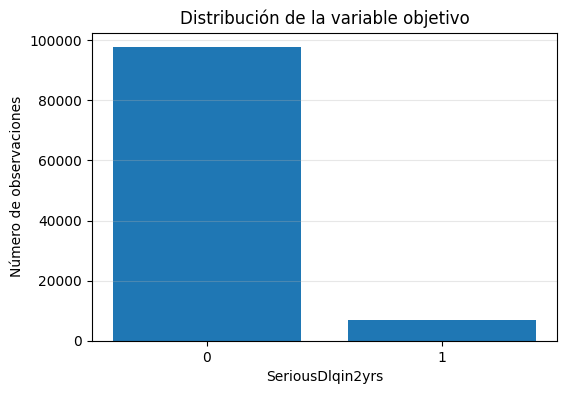

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(target_counts[TARGET].astype(str), target_counts["n"])
plt.title("Distribución de la variable objetivo")
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Número de observaciones")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 4. Estadísticos descriptivos iniciales

La tabla siguiente resume posición, dispersión y percentiles. En este dataset es especialmente importante mirar `p99` y `max`, porque varias variables financieras suelen tener valores extremos que deforman los histogramas.

In [12]:
def describe_numeric(df: pd.DataFrame, columns: Optional[List[str]] = None) -> pd.DataFrame:
    """
    Devuelve un resumen ampliado para variables numéricas.

    Incluye percentiles altos para detectar concentración a la izquierda y colas largas.
    """
    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()

    rows = []
    for col in columns:
        s = df[col].dropna()
        rows.append({
            "variable": col,
            "n": len(s),
            "missing": df[col].isna().sum(),
            "missing_pct": 100 * df[col].isna().mean(),
            "min": s.min() if len(s) else np.nan,
            "p01": s.quantile(0.01) if len(s) else np.nan,
            "p05": s.quantile(0.05) if len(s) else np.nan,
            "p25": s.quantile(0.25) if len(s) else np.nan,
            "median": s.median() if len(s) else np.nan,
            "mean": s.mean() if len(s) else np.nan,
            "p75": s.quantile(0.75) if len(s) else np.nan,
            "p95": s.quantile(0.95) if len(s) else np.nan,
            "p99": s.quantile(0.99) if len(s) else np.nan,
            "max": s.max() if len(s) else np.nan,
            "std": s.std() if len(s) else np.nan,
            "skew": s.skew() if len(s) else np.nan,
            "kurtosis": s.kurtosis() if len(s) else np.nan,
        })

    return pd.DataFrame(rows).sort_values("variable").reset_index(drop=True)

numeric_summary_raw = describe_numeric(raw_train)
numeric_summary_raw

,variable,n,missing,missing_pct,min,p01,p05,p25,median,mean,p75,p95,p99,max,std,skew,kurtosis
0,DebtRatio,104669,0,0.0000,0.0000,0.0000,0.0050,0.1767,0.3675,355.2705,0.8747,"2,470.0000","5,008.0000","329,664.0000","2,002.5155",99.8922,"15,198.3989"
1,MonthlyIncome,84150,20519,19.6037,0.0000,0.0000,"1,300.0000","3,400.0000","5,400.0000","6,704.3697","8,250.0000","14,597.7500","25,000.0000","3,008,750.0000","15,372.4536",113.8311,"19,172.1061"
2,NumberOfDependents,101981,2688,2.5681,0.0000,0.0000,0.0000,0.0000,0.0000,0.7589,1.0000,3.0000,4.0000,13.0000,1.1150,1.5558,2.4537
3,NumberOfOpenCreditLinesAndLoans,104669,0,0.0000,0.0000,0.0000,2.0000,5.0000,8.0000,8.4621,11.0000,18.0000,24.0000,58.0000,5.1235,1.2240,3.1615
4,NumberOfTime30-59DaysPastDueNotWorse,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3997,0.0000,2.0000,4.0000,98.0000,3.9383,23.9879,590.8447
5,NumberOfTime60-89DaysPastDueNotWorse,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2185,0.0000,1.0000,2.0000,98.0000,3.8977,24.8670,620.5665
6,NumberOfTimes90DaysLate,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2444,0.0000,1.0000,3.0000,98.0000,3.9129,24.5699,610.2678
7,NumberRealEstateLoansOrLines,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0196,2.0000,3.0000,4.0000,54.0000,1.1343,3.7663,73.2144
8,RevolvingUtilizationOfUnsecuredLines,104669,0,0.0000,0.0000,0.0000,0.0000,0.0302,0.1547,6.1649,0.5588,1.0000,1.1078,"22,198.0000",218.0251,58.8569,"4,405.4525"
9,SeriousDlqin2yrs,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0670,0.0000,1.0000,1.0000,1.0000,0.2501,3.4631,9.9931


Observamos que las variables
* NumberOfTime30-59DaysPastDueNotWorse
* NumberOfTime60-89DaysPastDueNotWorse
* NumberOfTimes90DaysLate
tienen un máxio de 98 que probablemente indiquen vacíos.

In [13]:
raw_train['NumberOfTime30-59DaysPastDueNotWorse'].value_counts()

NumberOfTime30-59DaysPastDueNotWorse
0     87895
1     11244
2      3224
3      1249
4       496
5       238
98      162
6        96
7        31
8        19
9         7
10        3
96        3
12        2
Name: count, dtype: int64

In [14]:
raw_train['NumberOfTime60-89DaysPastDueNotWorse'].value_counts()

NumberOfTime60-89DaysPastDueNotWorse
0     99424
1      3967
2       780
3       226
98      162
4        65
5        21
6        12
7         7
96        3
8         2
Name: count, dtype: int64

In [15]:
raw_train['NumberOfTimes90DaysLate'].value_counts()

NumberOfTimes90DaysLate
0     98880
1      3671
2      1068
3       466
4       203
98      162
5        92
6        56
7        24
9        14
8        13
10        6
13        4
11        3
96        3
15        2
14        2
Name: count, dtype: int64

Vemos que efectivamente el 98 y el 96 en estas columnas es probable que indiquen vacíos, por los que también los imputaremos, tratándolos como vacíos. Es necesario hacerlo en prod y en train.

In [16]:
# Sustituimos los valores 98 y 96 por NaN 

cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for df in [raw_train, raw_prod]:
    df[cols] = df[cols].replace(98, np.nan)
    df[cols] = df[cols].replace(96, np.nan)

In [17]:
describe_numeric(raw_train[cols])

,variable,n,missing,missing_pct,min,p01,p05,p25,median,mean,p75,p95,p99,max,std,skew,kurtosis
0,NumberOfTime30-59DaysPastDueNotWorse,104504,165,0.1576,0.0000,0.0000,0.0000,0.0000,0.0000,0.2457,0.0000,2.0000,3.0000,12.0000,0.6938,4.1913,24.7290
1,NumberOfTime60-89DaysPastDueNotWorse,104504,165,0.1576,0.0000,0.0000,0.0000,0.0000,0.0000,0.0642,0.0000,0.0000,2.0000,8.0000,0.3268,7.3872,79.1519
2,NumberOfTimes90DaysLate,104504,165,0.1576,0.0000,0.0000,0.0000,0.0000,0.0000,0.0901,0.0000,1.0000,2.0000,15.0000,0.4840,9.3547,136.2815


Además de los códigos 98/96, hay un problema conocido en este dataset: `age = 0`. Una edad de 0 años no es un dato real, es un error de captura. Lo tratamos igual que los códigos 98/96: como un valor perdido, para que lo rellene el mismo imputador KNN en vez de dejarlo colar como si fuera un cliente real de 0 años (lo que distorsionaría vecinos, clipping y el propio modelo).

In [18]:
# age == 0 es un error de captura conocido en este dataset, no una edad real.
# Lo tratamos como missing (igual que hicimos con los códigos 98/96) para que
# el imputador KNN lo rellene usando clientes similares, en vez de dejar un
# valor imposible que distorsionaría distancias, clipping y el modelo.
print("Filas con age == 0 en construcción:", (raw_train["age"] == 0).sum())
print("Filas con age == 0 en producción:", (raw_prod["age"] == 0).sum())

for df in [raw_train, raw_prod]:
    df.loc[df["age"] == 0, "age"] = np.nan


Filas con age == 0 en construcción: 1
Filas con age == 0 en producción: 0


## 5. Análisis de valores perdidos

En este dataset los valores perdidos aparecen principalmente en variables de renta y dependientes. No deben eliminarse sin más: perderíamos muchas filas y además el hecho de que falte renta puede ser informativo.

Por eso haremos dos cosas:

1. Crear indicadores binarios de ausencia (`*_was_missing`).
2. Imputar los valores usando KNN, ajustado únicamente en construcción y aplicado después a producción.

In [19]:
def missing_report(train: pd.DataFrame, prod: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    """Crea un informe comparando missing en construcción y producción."""
    report = pd.DataFrame({
        "missing_train": train.isna().sum(),
        "missing_train_pct": 100 * train.isna().mean(),
    })

    if prod is not None:
        report["missing_prod"] = prod.isna().sum()
        report["missing_prod_pct"] = 100 * prod.isna().mean()

    return report.sort_values("missing_train_pct", ascending=False)

missing = missing_report(raw_train, raw_prod)
missing

,missing_train,missing_train_pct,missing_prod,missing_prod_pct
MonthlyIncome,20519,19.6037,8936,19.8578
NumberOfDependents,2688,2.5681,1186,2.6356
NumberOfTimes90DaysLate,165,0.1576,81,0.1800
NumberOfTime60-89DaysPastDueNotWorse,165,0.1576,81,0.1800
NumberOfTime30-59DaysPastDueNotWorse,165,0.1576,81,0.1800
age,1,0.0010,0,0.0000
SeriousDlqin2yrs,0,0.0000,45000,100.0000
RevolvingUtilizationOfUnsecuredLines,0,0.0000,0,0.0000
DebtRatio,0,0.0000,0,0.0000
NumberOfOpenCreditLinesAndLoans,0,0.0000,0,0.0000


In [20]:
# Analizamos si tener missing está asociado al target.
# Esto ayuda a decidir si debemos añadir flags de missing.
missing_effect_rows = []

for col in FEATURES:
    if raw_train[col].isna().any():
        flag = raw_train[col].isna()
        missing_effect_rows.append({
            "variable": col,
            "n_missing": flag.sum(),
            "default_rate_missing": raw_train.loc[flag, TARGET].mean(),
            "default_rate_not_missing": raw_train.loc[~flag, TARGET].mean(),
            "difference": raw_train.loc[flag, TARGET].mean() - raw_train.loc[~flag, TARGET].mean(),
        })

missing_effect = pd.DataFrame(missing_effect_rows)
missing_effect

,variable,n_missing,default_rate_missing,default_rate_not_missing,difference
0,age,1,0.0000,0.0670,-0.0670
1,NumberOfTime30-59DaysPastDueNotWorse,165,0.6000,0.0662,0.5338
2,MonthlyIncome,20519,0.0556,0.0698,-0.0143
3,NumberOfTimes90DaysLate,165,0.6000,0.0662,0.5338
4,NumberOfTime60-89DaysPastDueNotWorse,165,0.6000,0.0662,0.5338
5,NumberOfDependents,2688,0.0476,0.0675,-0.0199


## 6. Imputación KNN reutilizable

### Por qué KNN

La imputación KNN rellena un valor ausente buscando clientes parecidos según el resto de variables. Por ejemplo, para imputar `MonthlyIncome`, no usa una media global, sino valores de clientes con perfiles similares.

### Problema práctico

KNN depende de distancias. Si una variable está en miles de euros y otra en unidades, la variable con escala mayor domina la distancia. Por eso implementamos un imputador que:

1. Ajusta un `StandardScaler` con los datos de construcción.
2. Aplica KNN sobre variables escaladas.
3. Deshace el escalado para volver a las unidades originales.

Además, se guarda el objeto para poder aplicarlo después a producción y a cualquier scoring futuro.

In [21]:
# La clase ScaledKNNImputer vive ahora en preprocessing_utils.py, un fichero
# .py normal en la misma carpeta que los notebooks (no en una celda).
#
# Motivo: este objeto se guarda con joblib al final del notebook y se vuelve
# a cargar en los notebooks 02, 03 y 04, que corren en kernels distintos.
# Si la clase estuviera definida solo en esta celda, joblib.load() fallaría
# en esos notebooks con AttributeError: "Can't get attribute 'ScaledKNNImputer'
# on <module '__main__'>", porque no tendrían forma de saber qué es esa clase.
# Al definirla en un módulo importable, cualquier notebook que haga
# `from preprocessing_utils import ScaledKNNImputer` antes de cargar el
# joblib puede reconstruir el objeto sin problema.
from preprocessing_utils import ScaledKNNImputer


In [22]:
def add_missing_flags(train: pd.DataFrame, prod: pd.DataFrame, columns: Optional[List[str]] = None) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    """
    Añade columnas binarias indicando si el valor original era missing.

    Estas columnas se crean antes de imputar, porque después de imputar ya no sabríamos
    dónde estaban los huecos originales.
    """
    if columns is None:
        columns = [c for c in train.columns if train[c].isna().any() or prod[c].isna().any()]

    train_out = train.copy()
    prod_out = prod.copy()
    flag_cols = []

    for col in columns:
        flag_col = f"{col}_was_missing"
        train_out[flag_col] = train_out[col].isna().astype(int)
        prod_out[flag_col] = prod_out[col].isna().astype(int)
        flag_cols.append(flag_col)

    return train_out, prod_out, flag_cols

In [23]:
# Creamos copias de trabajo.
train = raw_train.copy()
prod = raw_prod.copy()


# Añadimos flags de missing usando construcción y producción.
train, prod, missing_flag_cols = add_missing_flags(train, prod,  
                                                    columns=[c for c in FEATURES if raw_train[c].isna().any() or raw_prod[c].isna().any()])

print("Flags de missing creados:", missing_flag_cols)

# --------------------------------------------------------------
# Los tres flags de missing de retrasos (30-59, 60-89, 90 días)
# marcan EXACTAMENTE las mismas filas: el código 98/96 aparecía a
# la vez en las tres columnas para cada cliente afectado. Son
# columnas idénticas (correlación = 1.00), así que nos quedamos con
# una sola, renombrada de forma más clara, y eliminamos las otras dos
# para no repetir la misma señal tres veces en el modelo.
# --------------------------------------------------------------
delinquency_flag_cols = [
    c for c in missing_flag_cols
    if c in [
        "NumberOfTime30-59DaysPastDueNotWorse_was_missing",
        "NumberOfTime60-89DaysPastDueNotWorse_was_missing",
        "NumberOfTimes90DaysLate_was_missing",
    ]
]

if len(delinquency_flag_cols) > 1:
    # Comprobamos que de verdad son idénticas antes de fusionarlas.
    identical_train = all(
        train[delinquency_flag_cols[0]].equals(train[c]) for c in delinquency_flag_cols[1:]
    )
    identical_prod = all(
        prod[delinquency_flag_cols[0]].equals(prod[c]) for c in delinquency_flag_cols[1:]
    )

    if identical_train and identical_prod:
        merged_flag_name = "DelinquencyFields_was_missing"
        train[merged_flag_name] = train[delinquency_flag_cols[0]]
        prod[merged_flag_name] = prod[delinquency_flag_cols[0]]

        train = train.drop(columns=delinquency_flag_cols)
        prod = prod.drop(columns=delinquency_flag_cols)

        missing_flag_cols = [c for c in missing_flag_cols if c not in delinquency_flag_cols] + [merged_flag_name]

        print(f"\nLos flags {delinquency_flag_cols} eran idénticos entre sí.")
        print(f"Se han fusionado en una sola columna: '{merged_flag_name}'.")
        print("Flags de missing finales:", missing_flag_cols)
    else:
        print("\nAviso: los flags de retrasos no son idénticos en este dataset, no se fusionan.")

# Columnas que se imputan con KNN: variables explicativas originales.
impute_cols = FEATURES.copy()

knn_imputer = ScaledKNNImputer(columns=impute_cols, n_neighbors=7, weights="distance", fit_sample_size=10000, random_state=RANDOM_STATE)
train_imputed = knn_imputer.fit_transform(train)
prod_imputed = knn_imputer.transform(prod)

print("\nMissing tras imputación en construcción:", train_imputed[impute_cols].isna().sum().sum())
print("Missing tras imputación en producción:", prod_imputed[impute_cols].isna().sum().sum())


Flags de missing creados: ['age_was_missing', 'NumberOfTime30-59DaysPastDueNotWorse_was_missing', 'MonthlyIncome_was_missing', 'NumberOfTimes90DaysLate_was_missing', 'NumberOfTime60-89DaysPastDueNotWorse_was_missing', 'NumberOfDependents_was_missing']

Los flags ['NumberOfTime30-59DaysPastDueNotWorse_was_missing', 'NumberOfTimes90DaysLate_was_missing', 'NumberOfTime60-89DaysPastDueNotWorse_was_missing'] eran idénticos entre sí.
Se han fusionado en una sola columna: 'DelinquencyFields_was_missing'.
Flags de missing finales: ['age_was_missing', 'MonthlyIncome_was_missing', 'NumberOfDependents_was_missing', 'DelinquencyFields_was_missing']



Missing tras imputación en construcción: 0
Missing tras imputación en producción: 0


In [24]:
# Vamos a ver algunos casos para explicar por qué esa imputación se ha hecho así. Por ejemplo, para la variable `MonthlyIncome`:

col = "MonthlyIncome"

missing_examples = train.index[train[col].isna()][:3]

for idx in missing_examples:
    explanation = knn_imputer.explain_imputation(
        original_df=train,
        imputed_df=train_imputed,
        column=col,
        row_index=idx,
        n_neighbors=7,
        display_columns=[
            "age",
            "DebtRatio",
            "RevolvingUtilizationOfUnsecuredLines",
            "NumberOfOpenCreditLinesAndLoans",
            "NumberRealEstateLoansOrLines",
            "NumberOfDependents",
        ],
    )

    display(explanation)

Explicación de imputación KNN
Fila imputada: 4
Variable imputada: MonthlyIncome
Valor original: nan
Valor imputado por KNNImputer: 3233.3161
Valor reconstruido desde vecinos: 3233.3161


,neighbor_rank,knn_distance,MonthlyIncome_neighbor_value,age,DebtRatio,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents
39699,1,0.1618,"2,916.0000",63.0000,0.1148,1.0000,2.0000,0.0000,0.0000
88128,2,0.2717,"1,886.0000",67.0000,0.2125,1.0706,1.0000,0.0000,1.0000
91569,3,0.3088,"3,800.0000",69.0000,0.0500,0.9102,2.0000,0.0000,0.0000
10916,4,0.4654,"7,783.0000",63.0000,0.1766,0.6243,4.0000,0.0000,1.0000
104605,5,0.5343,"3,100.0000",58.0000,0.0500,0.4152,2.0000,0.0000,1.0000
31330,6,0.5566,"1,800.0000",65.0000,0.0122,1.0000,0.0000,0.0000,0.0000
13685,7,0.6614,"2,000.0000",66.0000,0.5417,0.8151,5.0000,0.0000,1.0000


Explicación de imputación KNN
Fila imputada: 20
Variable imputada: MonthlyIncome
Valor original: nan
Valor imputado por KNNImputer: 3783.0531
Valor reconstruido desde vecinos: 3783.0531


,neighbor_rank,knn_distance,MonthlyIncome_neighbor_value,age,DebtRatio,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents
51505,1,0.1464,"3,417.0000",62.0000,0.1679,1.0000,1.0000,0.0000,0.0000
46100,2,0.2080,"3,419.0000",64.0000,0.1442,1.0000,2.0000,0.0000,0.0000
56522,3,0.2200,"2,974.0000",63.0000,0.0541,0.1573,2.0000,0.0000,0.0000
24338,4,0.2200,"2,168.0000",63.0000,0.0171,0.1249,2.0000,0.0000,0.0000
22117,5,0.2525,"2,700.0000",62.0000,0.2858,0.3366,2.0000,0.0000,0.0000
65503,6,0.2525,"2,883.0000",66.0000,0.1515,0.0000,2.0000,0.0000,0.0000
24520,7,0.2525,"9,622.0000",66.0000,0.0296,0.0000,2.0000,0.0000,0.0000


Explicación de imputación KNN
Fila imputada: 25
Variable imputada: MonthlyIncome
Valor original: nan
Valor imputado por KNNImputer: 1240.1918
Valor reconstruido desde vecinos: 1240.1918


,neighbor_rank,knn_distance,MonthlyIncome_neighbor_value,age,DebtRatio,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents
65470,1,0.5707,0.0000,46.0000,256.0000,0.0572,7.0000,0.0000,0.0000
84283,2,0.6253,0.0000,51.0000,548.0000,0.2043,10.0000,0.0000,0.0000
78244,3,0.6514,0.0000,53.0000,"1,763.0000",0.5419,10.0000,0.0000,0.0000
16508,4,0.6770,666.0000,49.0000,0.9190,0.1205,8.0000,0.0000,0.0000
28896,5,0.6773,"2,300.0000",45.0000,0.3972,0.8644,8.0000,0.0000,0.0000
90751,6,0.6773,"3,800.0000",45.0000,0.3341,0.0127,8.0000,0.0000,0.0000
32068,7,0.6774,"2,300.0000",49.0000,0.1717,0.3100,8.0000,0.0000,0.0000


Nota: la variable target no se puede tener en cuenta para buscar vecinos porque en el dataset de test no existe y se asignarían de diferente forma.

In [25]:
# Algunas variables deberían ser conteos enteros.
# Después de KNN pueden quedar decimales. Para mantener sentido financiero,
# redondeamos las variables de conteo y evitamos valores negativos.
# No incluimos MonthlyIncome porque es una variable continua, no un conteo.

count_cols = [
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]

for col in count_cols:
    if col in train_imputed.columns:
        train_imputed[col] = np.round(train_imputed[col]).clip(lower=0)
        prod_imputed[col] = np.round(prod_imputed[col]).clip(lower=0)

# La edad no puede ser 0 en un dataset real de crédito. No eliminamos todavía:
# lo analizamos como posible outlier o error de captura.
train_imputed[count_cols].head()

,age,NumberOfTime30-59DaysPastDueNotWorse,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,59.0000,0.0000,17.0000,0.0000,2.0000,0.0000,1.0000
1,74.0000,0.0000,16.0000,0.0000,1.0000,0.0000,0.0000
2,34.0000,0.0000,9.0000,0.0000,0.0000,0.0000,0.0000
3,66.0000,0.0000,4.0000,0.0000,1.0000,0.0000,0.0000
4,65.0000,1.0000,2.0000,0.0000,0.0000,0.0000,0.0000


## 7. Análisis exhaustivo de valores atípicos

En variables financieras es normal encontrar colas largas. El problema es que valores extremos pueden:

- distorsionar histogramas;
- afectar a escaladores basados en media y desviación típica;
- dificultar el entrenamiento de una red neuronal;
- dominar distancias en KNN o PCA.

No todos los outliers son errores: algunos representan clientes extremos reales. Por eso primero los cuantificamos y después aplicamos un tratamiento conservador.

In [26]:
def outlier_report(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """
    Calcula indicadores de outliers por IQR y percentiles extremos.
    """
    rows = []
    for col in columns:
        s = df[col].dropna().astype(float)
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower_iqr = q1 - 1.5 * iqr
        upper_iqr = q3 + 1.5 * iqr
        p001 = s.quantile(0.001)
        p01 = s.quantile(0.01)
        p99 = s.quantile(0.99)
        p999 = s.quantile(0.999)

        rows.append({
            "variable": col,
            "min": s.min(),
            "p001": p001,
            "p01": p01,
            "q1": q1,
            "median": s.median(),
            "q3": q3,
            "p99": p99,
            "p999": p999,
            "max": s.max(),
            "iqr": iqr,
            "lower_iqr": lower_iqr,
            "upper_iqr": upper_iqr,
            "n_outliers_iqr": int(((s < lower_iqr) | (s > upper_iqr)).sum()),
            "pct_outliers_iqr": 100 * ((s < lower_iqr) | (s > upper_iqr)).mean(),
            "n_above_p99": int((s > p99).sum()),
            "pct_above_p99": 100 * (s > p99).mean(),
        })

    return pd.DataFrame(rows).sort_values("pct_outliers_iqr", ascending=False)

outliers_raw = outlier_report(train_imputed, FEATURES)
outliers_raw

,variable,min,p001,p01,q1,median,q3,p99,p999,max,iqr,lower_iqr,upper_iqr,n_outliers_iqr,pct_outliers_iqr,n_above_p99,pct_above_p99
3,DebtRatio,0.0000,0.0000,0.0000,0.1767,0.3675,0.8747,"5,008.0000","10,735.9680","329,664.0000",0.6980,-0.8704,1.9217,21884,20.9078,1046,0.9993
2,NumberOfTime30-59DaysPastDueNotWorse,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,6.0000,12.0000,0.0000,0.0000,0.0000,16615,15.8738,892,0.8522
9,NumberOfDependents,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,4.0000,6.0000,13.0000,1.0000,-1.5000,2.5000,9346,8.9291,680,0.6497
6,NumberOfTimes90DaysLate,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,6.0000,15.0000,0.0000,0.0000,0.0000,5692,5.4381,889,0.8493
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,4.0000,8.0000,0.0000,0.0000,0.0000,5080,4.8534,333,0.3181
4,MonthlyIncome,-0.0000,0.0000,0.0000,"3,159.1936","5,000.0000","7,666.0000","25,000.0000","75,000.0000","3,008,750.0000","4,506.8064","-3,601.0160","14,426.2096",4610,4.4044,1007,0.9621
5,NumberOfOpenCreditLinesAndLoans,0.0000,0.0000,0.0000,5.0000,8.0000,11.0000,24.0000,34.3320,58.0000,6.0000,-4.0000,20.0000,2744,2.6216,997,0.9525
0,RevolvingUtilizationOfUnsecuredLines,0.0000,0.0000,0.0000,0.0302,0.1547,0.5588,1.1078,"1,647.6520","22,198.0000",0.5286,-0.7627,1.3517,563,0.5379,1046,0.9993
7,NumberRealEstateLoansOrLines,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,4.0000,9.0000,54.0000,2.0000,-3.0000,5.0000,554,0.5293,1021,0.9755
1,age,21.0000,21.0000,24.0000,41.0000,52.0000,63.0000,87.0000,93.3320,109.0000,22.0000,8.0000,96.0000,28,0.0268,877,0.8379


### 7.1 Visualización de distribuciones reales

En los histogramas originales muchas variables aparecen pegadas a la izquierda porque existen valores máximos enormes. Para verlo bien, por cada variable mostramos:

1. Histograma completo.
2. Histograma recortado al percentil 99.
3. Histograma con escala logarítmica en el eje Y.
4. Boxplot horizontal.

Esto permite distinguir entre la distribución de la mayoría de clientes y los casos extremos.

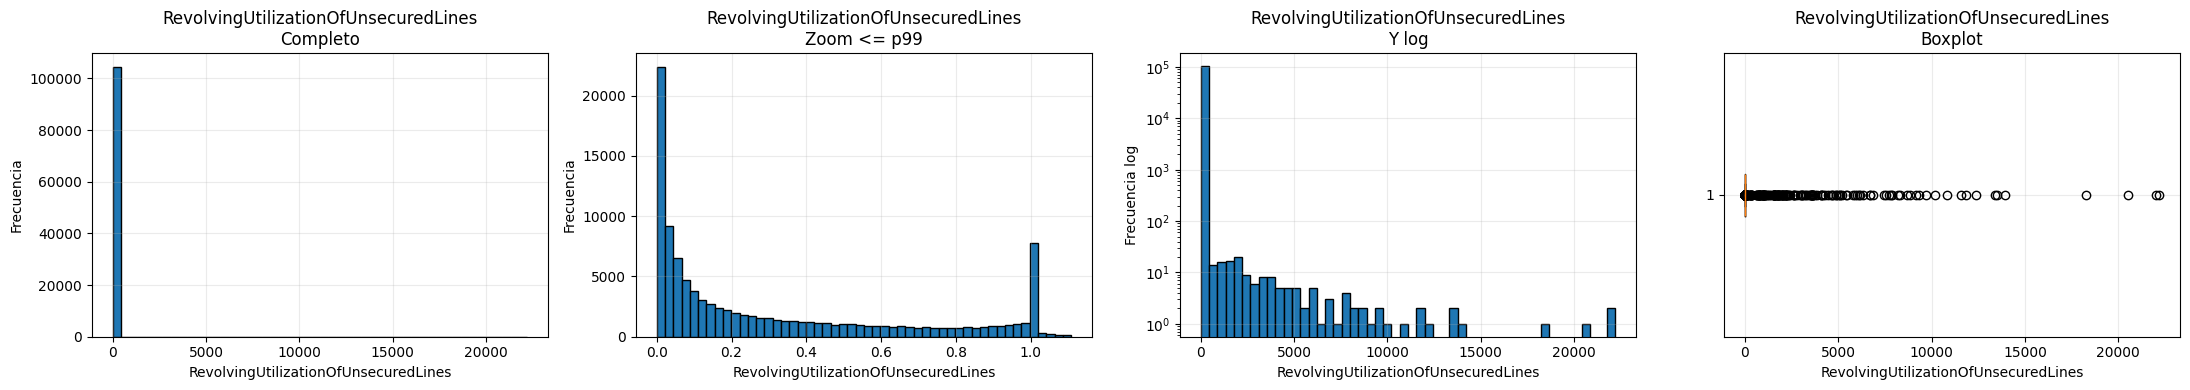

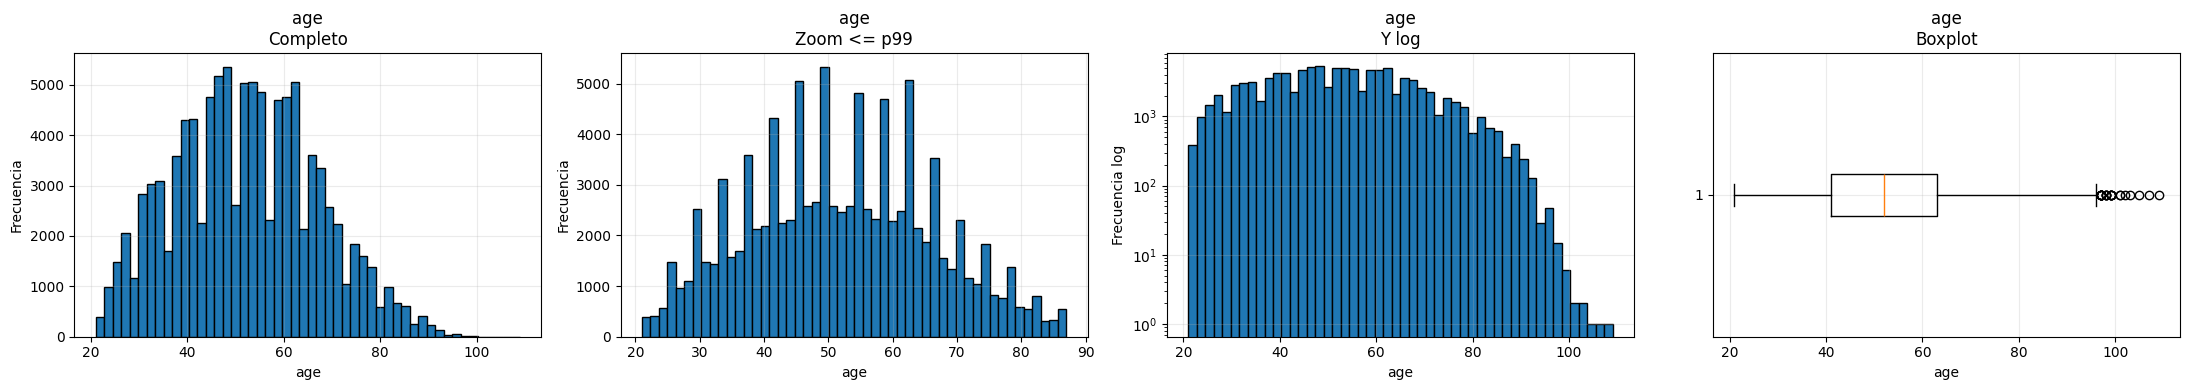

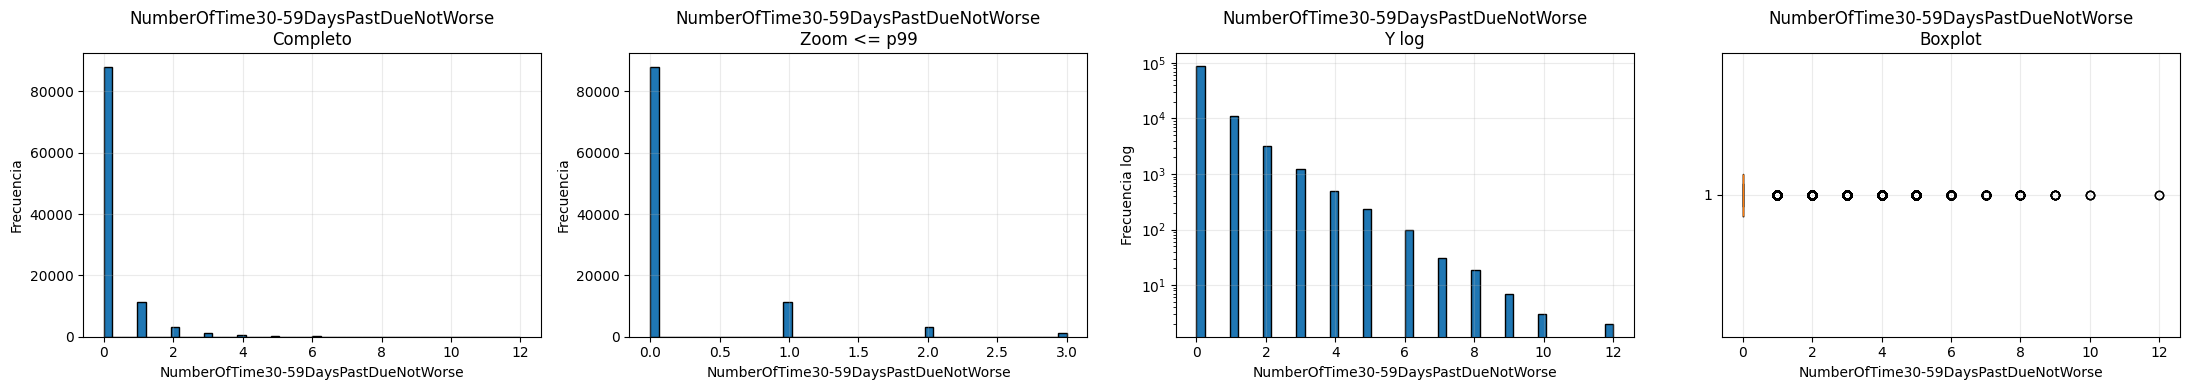

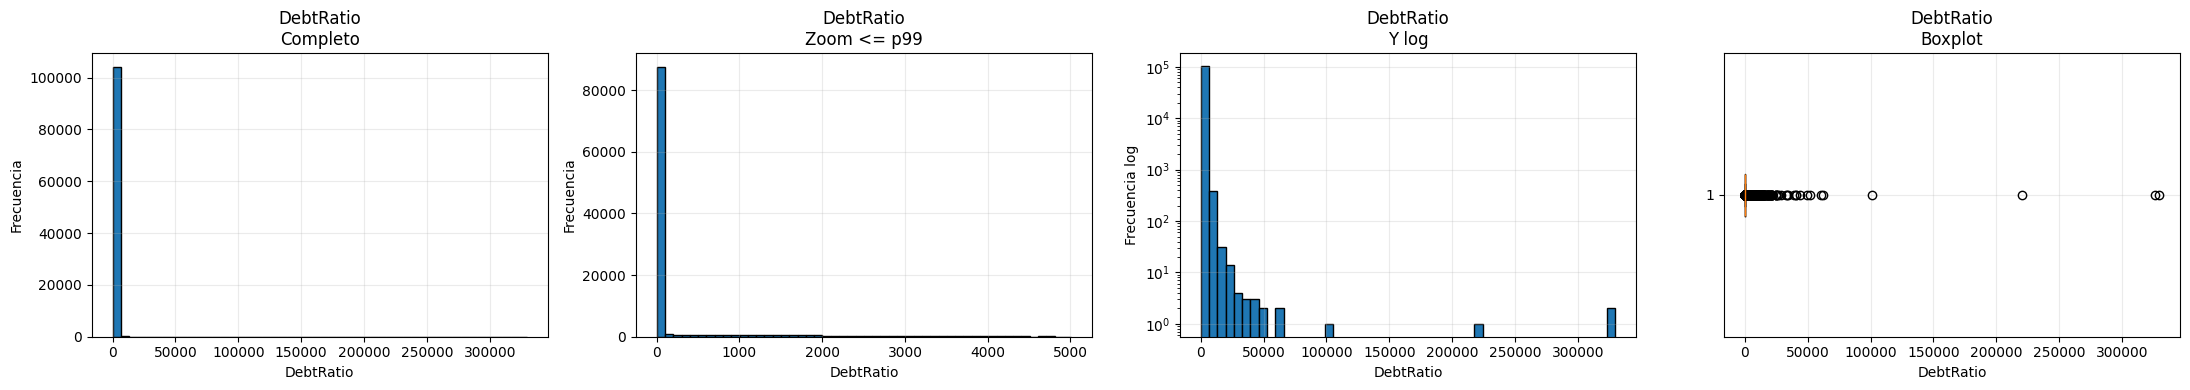

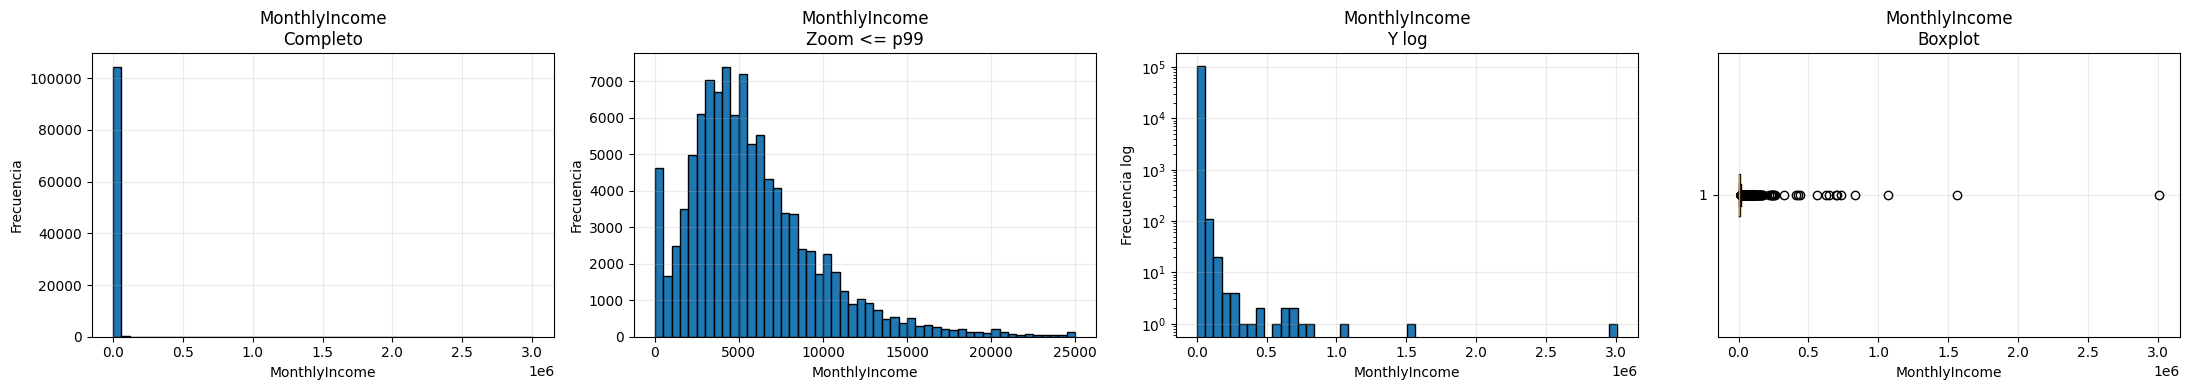

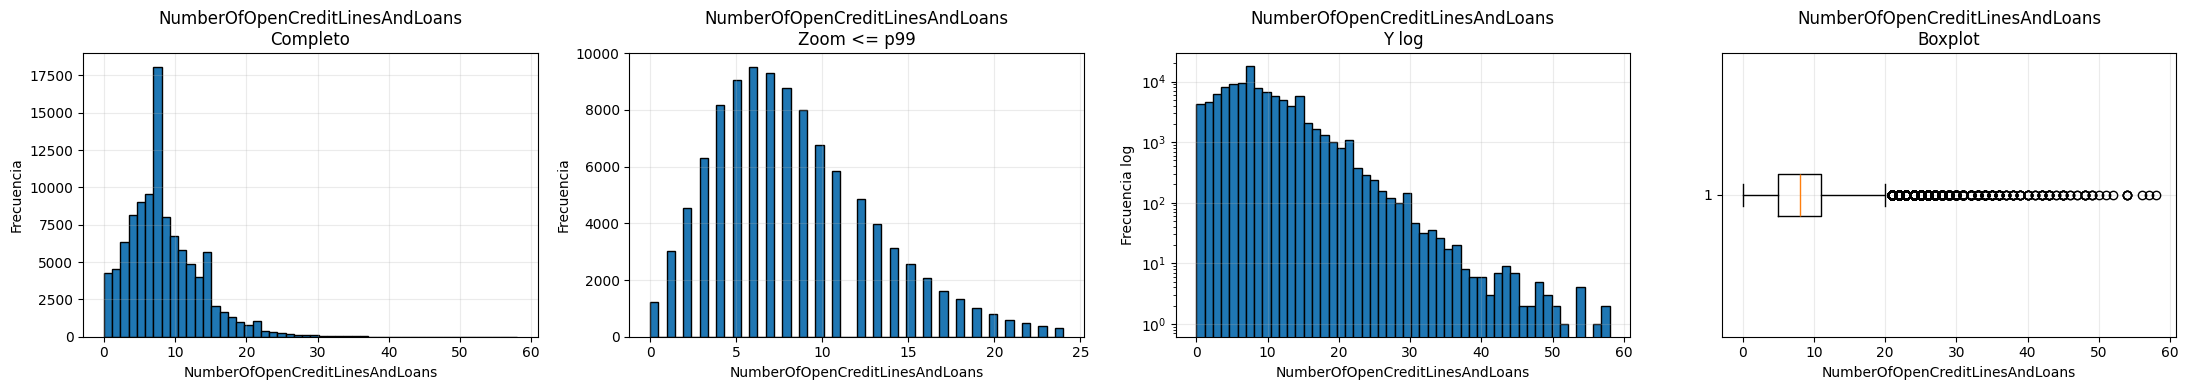

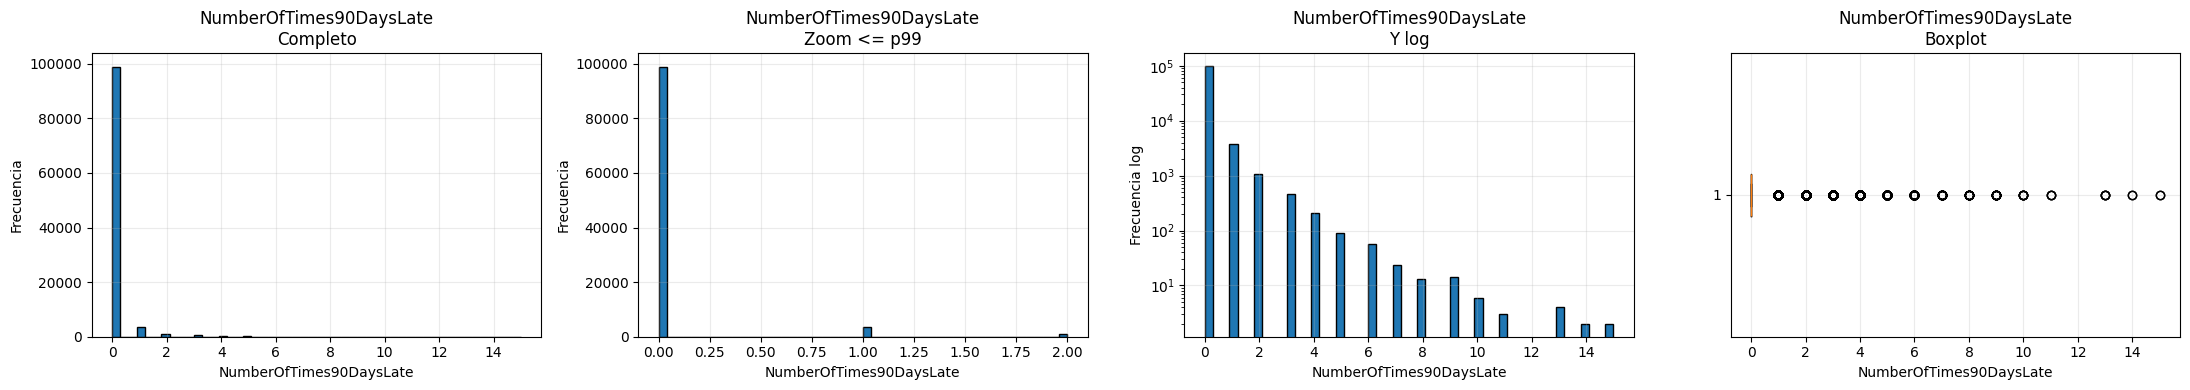

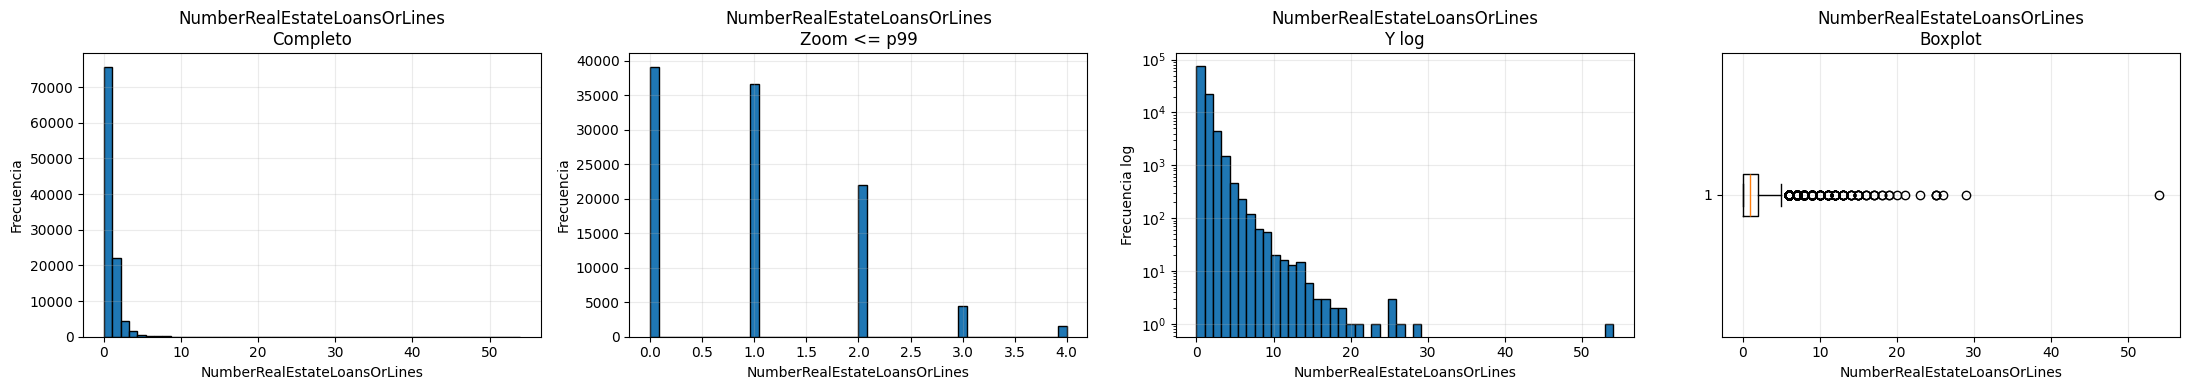

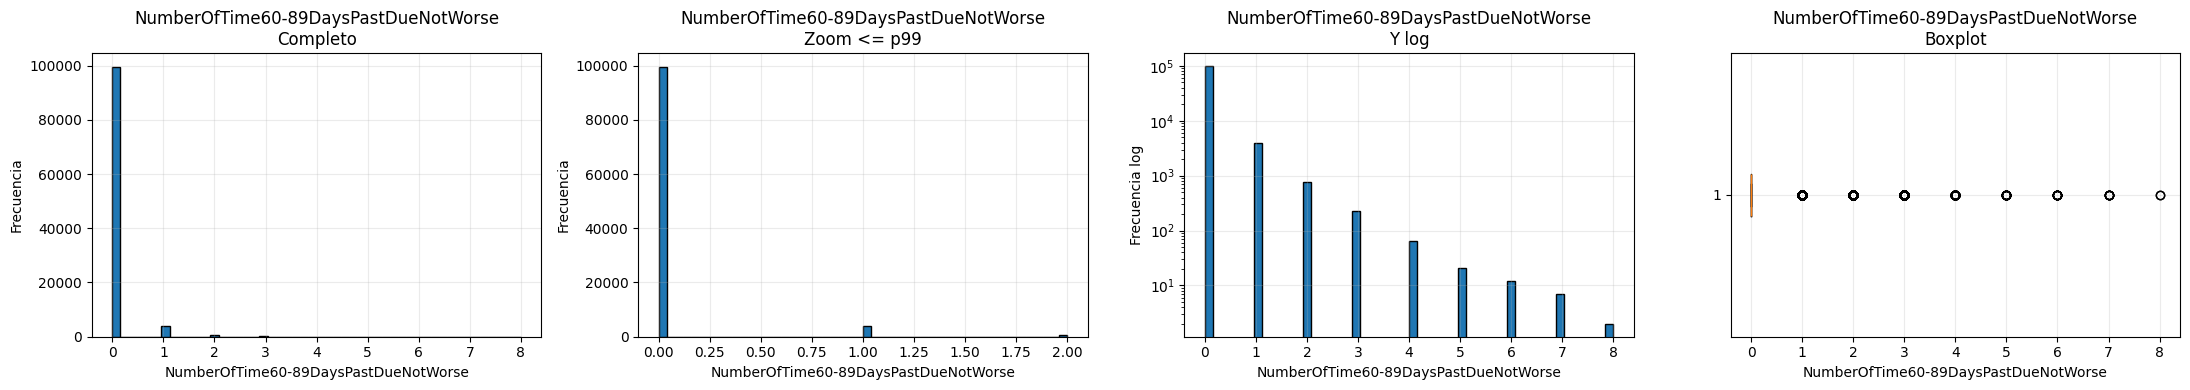

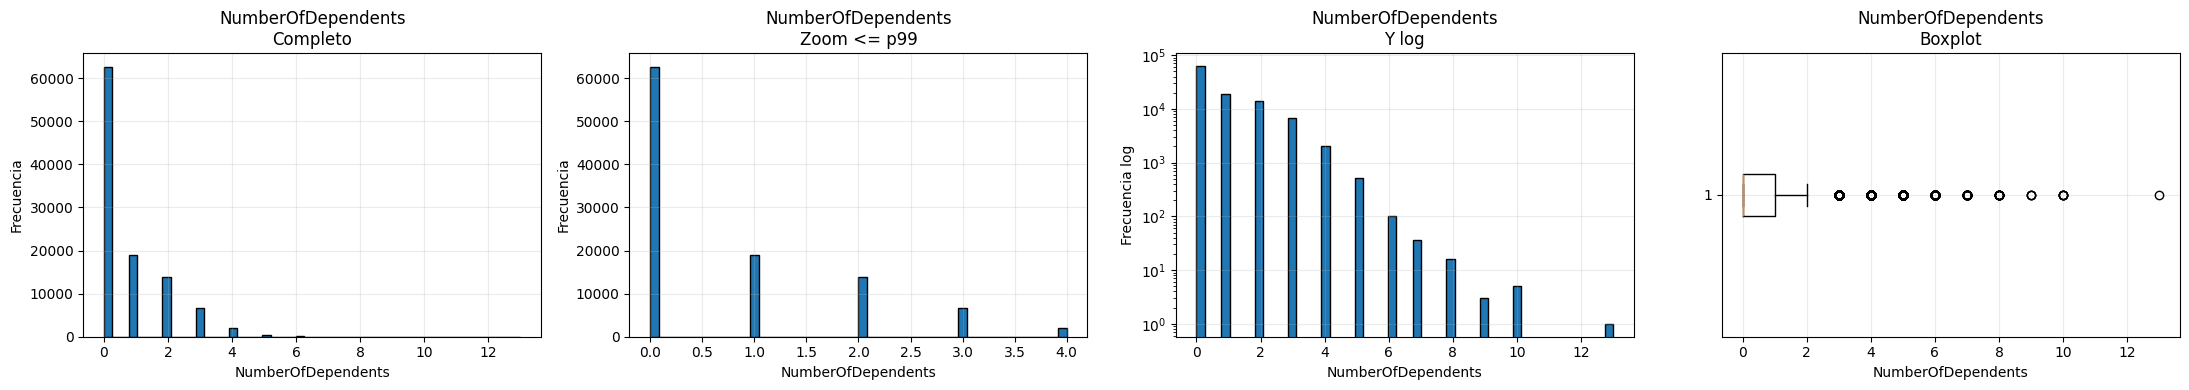

In [27]:
def plot_distribution_diagnostics(df: pd.DataFrame, columns: List[str], bins: int = 50, upper_quantile: float = 0.99):
    """
    Dibuja diagnóstico de distribución para cada variable.

    Se usa un gráfico por variable para evitar paneles enormes difíciles de leer.
    """
    for col in columns:
        s = df[col].dropna().astype(float)
        upper = s.quantile(upper_quantile)
        s_zoom = s[s <= upper]

        fig, axes = plt.subplots(1, 4, figsize=(22, 4))

        axes[0].hist(s, bins=bins, edgecolor="black")
        axes[0].set_title(f"{col}\nCompleto")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].grid(alpha=0.25)

        axes[1].hist(s_zoom, bins=bins, edgecolor="black")
        axes[1].set_title(f"{col}\nZoom <= p{int(upper_quantile * 100)}")
        axes[1].set_xlabel(col)
        axes[1].set_ylabel("Frecuencia")
        axes[1].grid(alpha=0.25)

        axes[2].hist(s, bins=bins, edgecolor="black")
        axes[2].set_yscale("log")
        axes[2].set_title(f"{col}\nY log")
        axes[2].set_xlabel(col)
        axes[2].set_ylabel("Frecuencia log")
        axes[2].grid(alpha=0.25)

        axes[3].boxplot(s, vert=False)
        axes[3].set_title(f"{col}\nBoxplot")
        axes[3].set_xlabel(col)
        axes[3].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

# Si quieres ejecutar solo algunas variables, cambia FEATURES por una lista, por ejemplo:
# ["DebtRatio", "MonthlyIncome", "RevolvingUtilizationOfUnsecuredLines"]
plot_distribution_diagnostics(train_imputed, FEATURES)

### 7.2 Decisión de tratamiento de outliers

Para una red neuronal y un bandit contextual conviene evitar que valores extremos dominen el aprendizaje. Usaremos un tratamiento conservador:

- No eliminamos filas.
- Ajustamos límites de clipping con construcción.
- Aplicamos los mismos límites a construcción y producción.
- Usamos percentiles 0.1 % y 99.9 % para no destruir demasiada información.

Esto es una winsorización suave: reduce el impacto de extremos muy raros, pero conserva el orden y la mayoría de la variabilidad.

In [28]:
def fit_clipping_limits(
    df: pd.DataFrame,
    columns: List[str],
    lower_q: float = 0.001,
    upper_q: float = 0.999,
) -> Dict[str, Tuple[float, float]]:
    """Aprende límites de clipping a partir del dataset de construcción."""
    limits = {}
    for col in columns:
        s = df[col].dropna().astype(float)
        lower = float(s.quantile(lower_q))
        upper = float(s.quantile(upper_q))
        limits[col] = (lower, upper)
    return limits


def apply_clipping(df: pd.DataFrame, limits: Dict[str, Tuple[float, float]]) -> pd.DataFrame:
    """Aplica límites de clipping previamente ajustados."""
    out = df.copy()
    for col, (lower, upper) in limits.items():
        out[col] = out[col].clip(lower=lower, upper=upper)
    return out


# Variables sobre las que aplicamos clipping.
# Excluimos flags binarios de missing y el target.
clip_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
]
clipping_limits = fit_clipping_limits(train_imputed, clip_cols, lower_q=0.001, upper_q=0.999)

train_clipped = apply_clipping(train_imputed, clipping_limits)
prod_clipped = apply_clipping(prod_imputed, clipping_limits)

pd.DataFrame([
    {"variable": col, "lower_limit": lim[0], "upper_limit": lim[1]}
    for col, lim in clipping_limits.items()
]).sort_values("variable")

,variable,lower_limit,upper_limit
1,DebtRatio,0.0000,"10,735.9680"
2,MonthlyIncome,0.0000,"75,000.0000"
0,RevolvingUtilizationOfUnsecuredLines,0.0000,"1,647.6520"


## 8. Feature engineering interpretativo

Creamos variables sencillas que suelen tener sentido financiero:

- `TotalPastDueEvents`: suma de retrasos de 30-59, 60-89 y 90+ días.
- `HasAnyPastDue`: indica si hubo cualquier retraso.
- `Has90DaysLate`: indica si hubo retrasos de 90+ días.
- `CreditLinesPerRealEstateLoan`: relación entre líneas abiertas totales e inmobiliarias.
- Transformaciones `log1p` para variables con colas largas.

**Decisión importante (1): originales vs. `log1p`.** Calculamos la versión `log1p` de las variables más asimétricas, pero **no metemos las dos versiones (original y log1p) al mismo tiempo en `FINAL_FEATURES`**. Si lo hiciéramos, ambas llevarían prácticamente la misma señal, y eso perjudica justo la parte de auditoría de la práctica: el árbol subrogado repartiría cortes de forma poco consistente entre ellas, y SHAP diluiría en dos barras medianas lo que en realidad es una sola señal. Como los modelos de la Práctica 2 ya escalan las variables con `StandardScaler`, nos quedamos con la variable en **escala original** y descartamos la versión `log1p` (se calcula igualmente, por si se quiere comparar puntualmente).

**Decisión importante (2): variables de conteo vs. sus indicadores binarios derivados.** `Has90DaysLate`, `HasAnyPastDue` y `HasDependents` son indicadores 0/1 calculados directamente a partir de otra variable que también dejamos en el dataset (`NumberOfTimes90DaysLate`, `TotalPastDueEvents`, `NumberOfDependents`). La correlación entre cada indicador y su variable de origen es altísima (0.96-1.00): en la práctica, casi no aportan información nueva, solo repiten "¿es mayor que cero?" de una variable que ya está. Aplicamos el mismo criterio que con el log1p: nos quedamos con la variable de **conteo** (más informativa, porque conserva la magnitud, no solo si hubo o no evento) y descartamos el indicador binario derivado de `FINAL_FEATURES`.

In [29]:
def add_credit_features(df: pd.DataFrame) -> pd.DataFrame:
    """Añade variables derivadas de riesgo crediticio."""
    out = df.copy()

    delinquency_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
    ]

    out["TotalPastDueEvents"] = out[delinquency_cols].sum(axis=1)
    # Indicadores binarios: se calculan para poder inspeccionarlos y para
    # usarlos en el modelo subrogado/reglas si interesa mostrar un corte
    # binario simple, pero NO entran en FINAL_FEATURES porque casi duplican
    # a su variable de conteo de origen (ver celda markdown de arriba).
    out["HasAnyPastDue"] = (out["TotalPastDueEvents"] > 0).astype(int)
    out["Has90DaysLate"] = (out["NumberOfTimes90DaysLate"] > 0).astype(int)
    out["HasDependents"] = (out["NumberOfDependents"] > 0).astype(int)

    out["CreditLinesPerRealEstateLoan"] = (
        out["NumberOfOpenCreditLinesAndLoans"] / (1 + out["NumberRealEstateLoansOrLines"])
    )

    # log1p es log(1+x). Funciona con ceros y reduce la cola derecha.
    # Se calcula para poder inspeccionarla, pero NO se usa en FINAL_FEATURES.
    log_cols = [
        "RevolvingUtilizationOfUnsecuredLines",
        "DebtRatio",
        "MonthlyIncome",
        "NumberOfOpenCreditLinesAndLoans",
        "NumberRealEstateLoansOrLines",
        "TotalPastDueEvents",
    ]

    for col in log_cols:
        safe_values = out[col].clip(lower=0)
        out[f"{col}_log1p"] = np.log1p(safe_values)

    return out

train_fe = add_credit_features(train_clipped)
prod_fe = add_credit_features(prod_clipped)

# Columnas redundantes que se calculan para inspección pero se excluyen
# del conjunto final de features del modelo:
# - versiones log1p (casi idénticas a la variable original tras escalar)
# - indicadores binarios derivados (casi idénticos a su variable de conteo)
LOG1P_REDUNDANT_COLS = [c for c in train_fe.columns if c.endswith("_log1p")]
DERIVED_BINARY_REDUNDANT_COLS = ["Has90DaysLate", "HasAnyPastDue", "HasDependents"]
REDUNDANT_COLS = LOG1P_REDUNDANT_COLS + DERIVED_BINARY_REDUNDANT_COLS

FINAL_FEATURES = [
    c for c in train_fe.columns
    if c != TARGET and c not in REDUNDANT_COLS
]

print("Columnas log1p descartadas de FINAL_FEATURES (redundantes):", LOG1P_REDUNDANT_COLS)
print("Indicadores binarios descartados de FINAL_FEATURES (redundantes):", DERIVED_BINARY_REDUNDANT_COLS)
print("Número de features finales:", len(FINAL_FEATURES))
print(FINAL_FEATURES)


Columnas log1p descartadas de FINAL_FEATURES (redundantes): ['RevolvingUtilizationOfUnsecuredLines_log1p', 'DebtRatio_log1p', 'MonthlyIncome_log1p', 'NumberOfOpenCreditLinesAndLoans_log1p', 'NumberRealEstateLoansOrLines_log1p', 'TotalPastDueEvents_log1p']
Indicadores binarios descartados de FINAL_FEATURES (redundantes): ['Has90DaysLate', 'HasAnyPastDue', 'HasDependents']
Número de features finales: 16
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'age_was_missing', 'MonthlyIncome_was_missing', 'NumberOfDependents_was_missing', 'DelinquencyFields_was_missing', 'TotalPastDueEvents', 'CreditLinesPerRealEstateLoan']


## 9. Relación de variables con la variable objetivo

Para variables numéricas, una forma útil de entender su relación con el riesgo es calcular la tasa de default por deciles. Así se ve si el riesgo aumenta o disminuye de forma ordenada.

Esta sección no es modelado todavía. Es análisis descriptivo para entender qué puede aprender el modelo.

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 0.00321]",10467,0.0261,0.0000,0.0032,2.6082
1,"(0.00321, 0.0194]",10467,0.0143,0.0032,0.0194,1.4331
2,"(0.0194, 0.0437]",10467,0.0133,0.0194,0.0437,1.3280
3,"(0.0437, 0.0837]",10467,0.0190,0.0437,0.0837,1.9012
4,"(0.0837, 0.155]",10467,0.0241,0.0837,0.1547,2.4076
5,"(0.155, 0.271]",10466,0.0352,0.1547,0.2711,3.5161
6,"(0.271, 0.446]",10467,0.0508,0.2712,0.4460,5.0826
7,"(0.446, 0.698]",10467,0.0872,0.4460,0.6978,8.7227
8,"(0.698, 0.979]",10467,0.1653,0.6979,0.9790,16.5281
9,"(0.979, 1647.652]",10467,0.2349,0.9790,"1,647.6520",23.4929


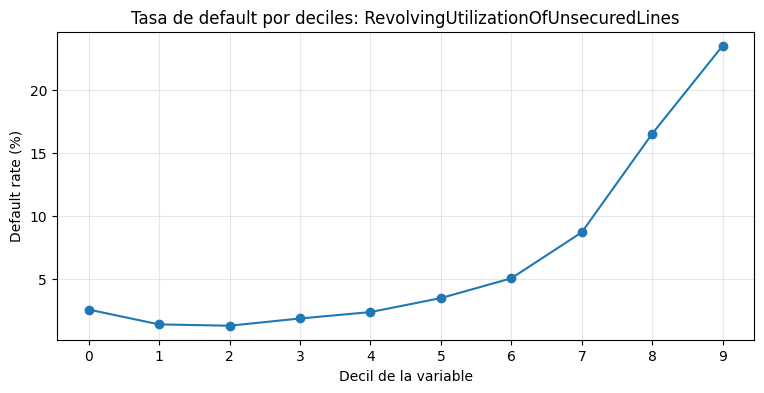

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(20.999, 33.0]",11936,0.1150,21.0000,33.0000,11.5030
1,"(33.0, 39.0]",10514,0.0946,34.0000,39.0000,9.4636
2,"(39.0, 44.0]",11063,0.0894,40.0000,44.0000,8.9397
3,"(44.0, 48.0]",10275,0.0808,45.0000,48.0000,8.0779
4,"(48.0, 52.0]",10376,0.0757,49.0000,52.0000,7.5655
5,"(52.0, 56.0]",9924,0.0635,53.0000,56.0000,6.3482
6,"(56.0, 60.0]",9293,0.0497,57.0000,60.0000,4.9715
7,"(60.0, 65.0]",11558,0.0407,61.0000,65.0000,4.0664
8,"(65.0, 72.0]",9890,0.0269,66.0000,72.0000,2.6896
9,"(72.0, 109.0]",9840,0.0218,73.0000,109.0000,2.1850


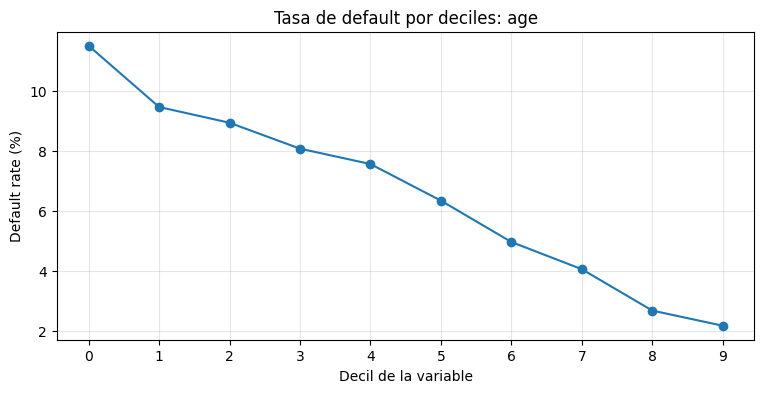

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,88054,0.0413,0.0000,0.0000,4.1304
1,1.0000,11250,0.1484,1.0000,1.0000,14.8356
2,2.0000,3224,0.2736,2.0000,2.0000,27.3573
3,3.0000,1249,0.3555,3.0000,3.0000,35.5484
4,4.0000,496,0.4093,4.0000,4.0000,40.9274
5,5.0000,238,0.4244,5.0000,5.0000,42.4370
6,6.0000,96,0.5104,6.0000,6.0000,51.0417
7,7.0000,31,0.5484,7.0000,7.0000,54.8387
8,8.0000,19,0.3158,8.0000,8.0000,31.5789
9,9.0000,7,0.4286,9.0000,9.0000,42.8571


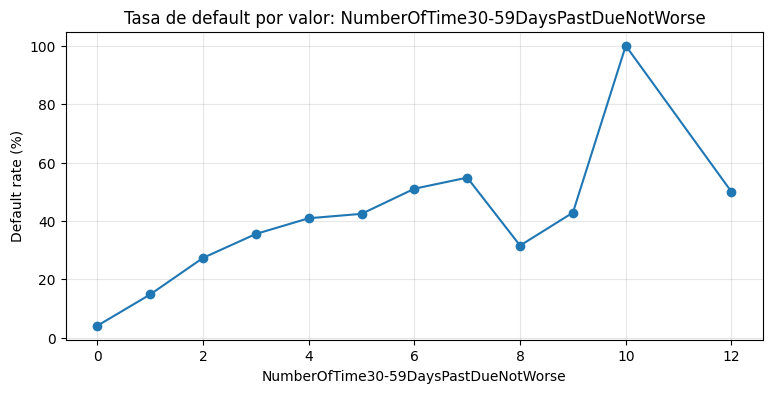

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 0.0343]",10467,0.0559,0.0000,0.0343,5.5890
1,"(0.0343, 0.136]",10467,0.0717,0.0343,0.1361,7.1654
2,"(0.136, 0.215]",10467,0.0610,0.1361,0.2150,6.1049
3,"(0.215, 0.288]",10467,0.0535,0.2151,0.2881,5.3501
4,"(0.288, 0.367]",10467,0.0536,0.2881,0.3675,5.3597
5,"(0.367, 0.468]",10466,0.0681,0.3675,0.4675,6.8125
6,"(0.468, 0.651]",10467,0.0827,0.4675,0.6506,8.2736
7,"(0.651, 4.0]",10525,0.1140,0.6506,4.0000,11.4014
8,"(4.0, 1288.0]",10411,0.0605,4.0045,"1,288.0000",6.0513
9,"(1288.0, 10735.968]",10465,0.0488,"1,289.0000","10,735.9680",4.8829


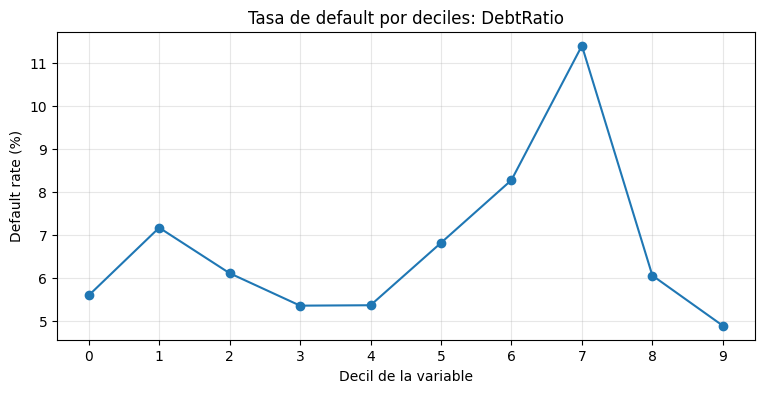

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 1710.0]",10469,0.0648,0.0000,"1,710.0000",6.4763
1,"(1710.0, 2766.0]",10467,0.0924,"1,710.5287","2,766.0000",9.2386
2,"(2766.0, 3502.855]",10465,0.0909,"2,766.2024","3,502.6455",9.0874
3,"(3502.855, 4252.481]",10467,0.0790,"3,503.1684","4,252.3878",7.9010
4,"(4252.481, 5000.0]",10654,0.0707,"4,252.8560","5,000.0000",7.0678
5,"(5000.0, 5958.0]",10285,0.0656,"5,000.0991","5,958.0000",6.5630
6,"(5958.0, 7000.0]",10973,0.0600,"5,958.3206","7,000.0000",5.9965
7,"(7000.0, 8500.0]",10334,0.0530,"7,000.1231","8,500.0000",5.3029
8,"(8500.0, 10966.112]",10088,0.0485,"8,500.4834","10,966.0000",4.8473
9,"(10966.112, 75000.0]",10467,0.0448,"10,966.5578","75,000.0000",4.4807


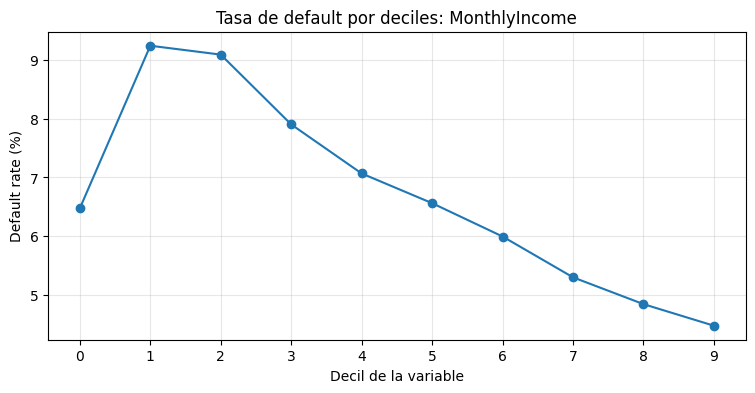

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 3.0]",15099,0.1081,0.0000,3.0000,10.8087
1,"(3.0, 4.0]",8178,0.0654,4.0000,4.0000,6.5419
2,"(4.0, 5.0]",9041,0.0653,5.0000,5.0000,6.5258
3,"(5.0, 7.0]",18823,0.0556,6.0000,7.0000,5.5570
4,"(7.0, 8.0]",8793,0.0478,8.0000,8.0000,4.7765
5,"(8.0, 9.0]",7991,0.0564,9.0000,9.0000,5.6438
6,"(9.0, 10.0]",6752,0.0607,10.0000,10.0000,6.0723
7,"(10.0, 12.0]",10717,0.0586,11.0000,12.0000,5.8598
8,"(12.0, 15.0]",9685,0.0659,13.0000,15.0000,6.5875
9,"(15.0, 58.0]",9590,0.0693,16.0000,58.0000,6.9343


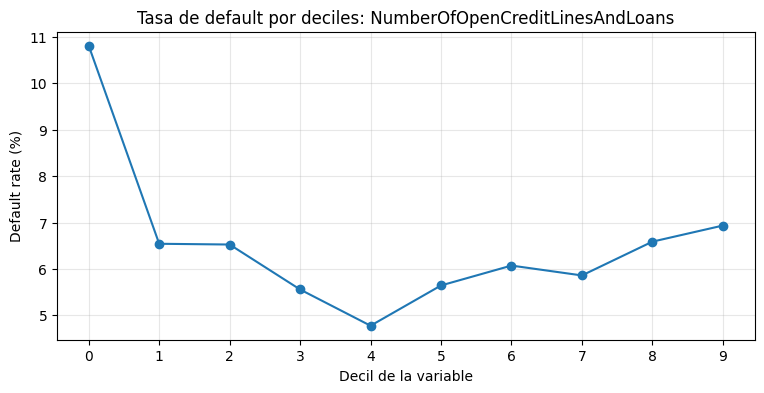

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,98977,0.0470,0.0000,0.0000,4.7041
1,1.0000,3725,0.3385,1.0000,1.0000,33.8523
2,2.0000,1078,0.5037,2.0000,2.0000,50.3711
3,3.0000,468,0.5897,3.0000,3.0000,58.9744
4,4.0000,205,0.6683,4.0000,4.0000,66.8293
5,5.0000,92,0.6413,5.0000,5.0000,64.1304
6,6.0000,56,0.6250,6.0000,6.0000,62.5000
7,7.0000,24,0.7917,7.0000,7.0000,79.1667
8,8.0000,13,0.6923,8.0000,8.0000,69.2308
9,9.0000,14,0.7143,9.0000,9.0000,71.4286


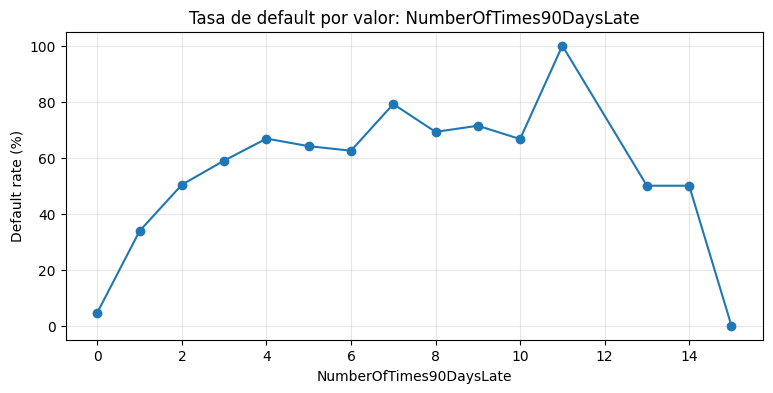

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 1.0]",75716,0.0684,0.0000,1.0000,6.8400
1,"(1.0, 2.0]",21976,0.0566,2.0000,2.0000,5.6562
2,"(2.0, 54.0]",6977,0.0850,3.0000,54.0000,8.4994


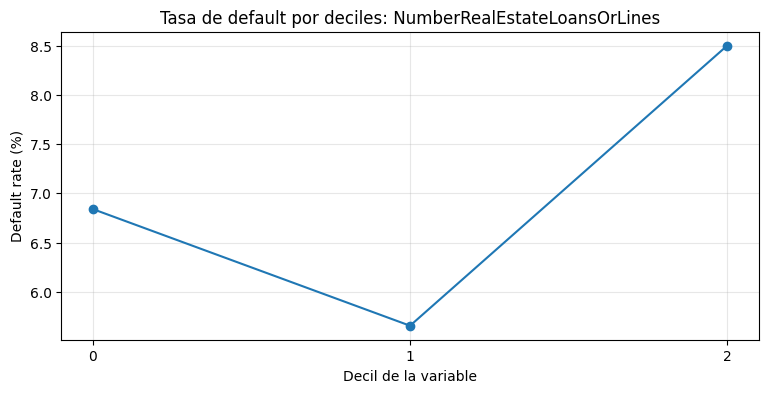

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,99589,0.0519,0.0000,0.0000,5.1853
1,1.0000,3967,0.3179,1.0000,1.0000,31.7872
2,2.0000,780,0.4987,2.0000,2.0000,49.8718
3,3.0000,226,0.5796,3.0000,3.0000,57.9646
4,4.0000,65,0.6308,4.0000,4.0000,63.0769
5,5.0000,21,0.6190,5.0000,5.0000,61.9048
6,6.0000,12,0.8333,6.0000,6.0000,83.3333
7,7.0000,7,0.7143,7.0000,7.0000,71.4286
8,8.0000,2,0.5000,8.0000,8.0000,50.0000


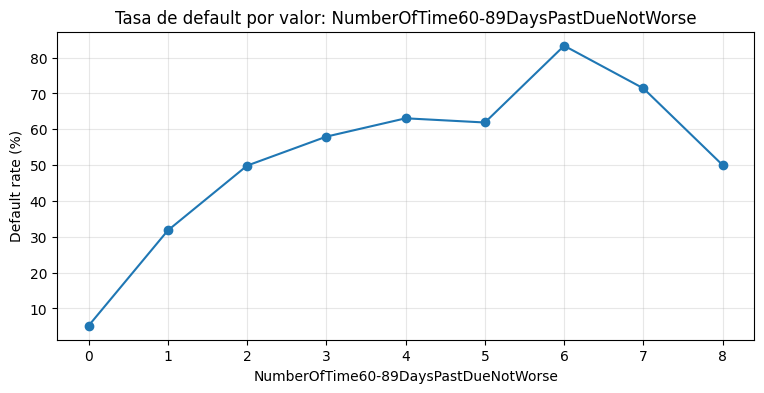

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,62676,0.0575,0.0000,0.0000,5.7518
1,1.0000,18871,0.0761,1.0000,1.0000,7.6096
2,2.0000,13776,0.0806,2.0000,2.0000,8.0648
3,3.0000,6654,0.0866,3.0000,3.0000,8.6564
4,4.0000,2012,0.1064,4.0000,4.0000,10.6362
5,5.0000,515,0.0971,5.0000,5.0000,9.7087
6,6.0000,103,0.1650,6.0000,6.0000,16.5049
7,7.0000,37,0.1351,7.0000,7.0000,13.5135
8,8.0000,16,0.0625,8.0000,8.0000,6.2500
9,9.0000,3,0.0000,9.0000,9.0000,0.0000


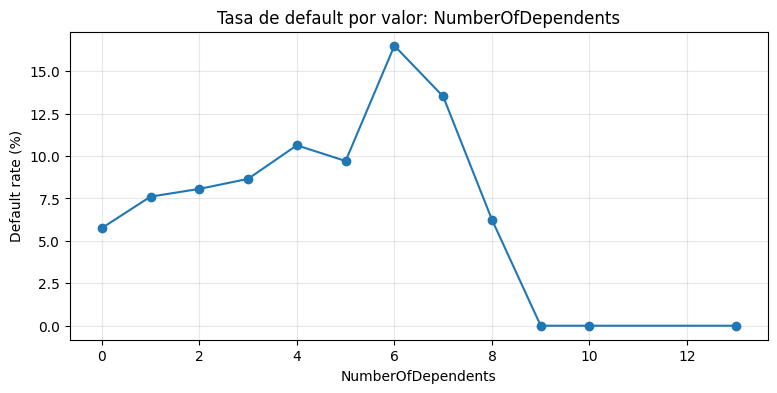

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,104668,0.0670,0,0,6.7021
1,1,1,0.0000,1,1,0.0000


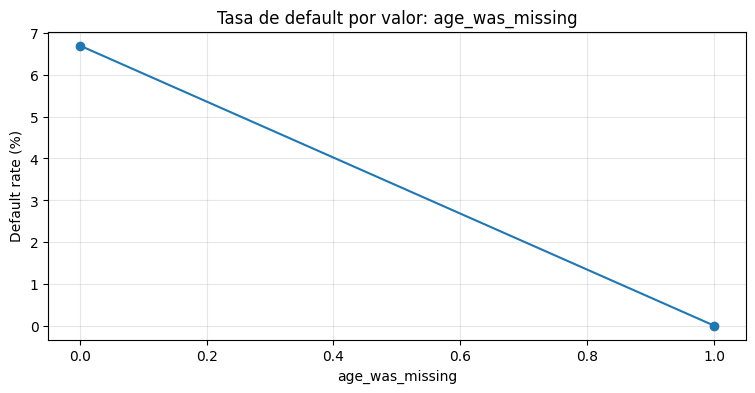

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,84150,0.0698,0,0,6.9816
1,1,20519,0.0556,1,1,5.5558


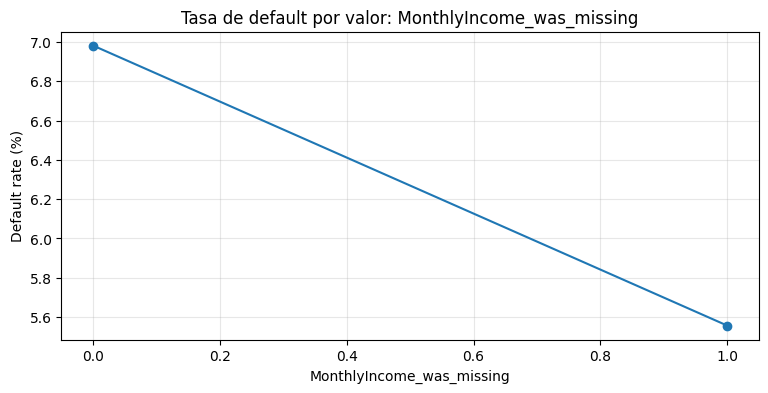

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,101981,0.0675,0,0,6.7532
1,1,2688,0.0476,1,1,4.7619


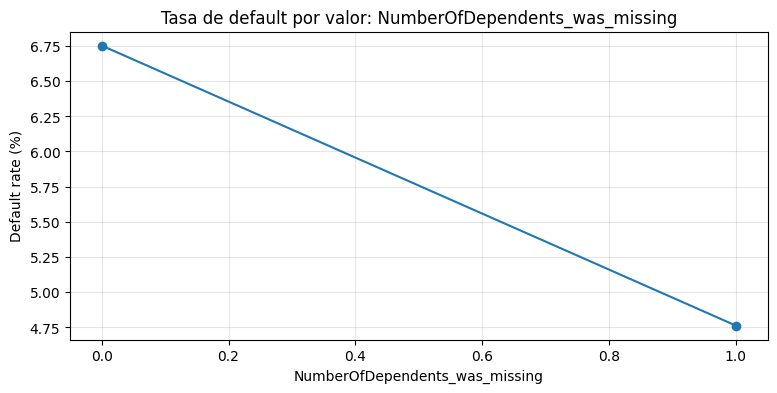

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,104504,0.0662,0,0,6.6179
1,1,165,0.6000,1,1,60.0000


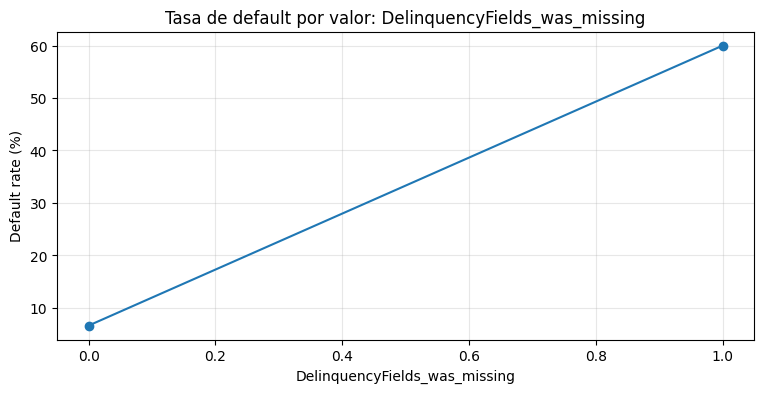

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,83566,0.0280,0.0000,0.0000,2.8038
1,1.0000,12096,0.1238,1.0000,1.0000,12.3843
2,2.0000,4183,0.2436,2.0000,2.0000,24.3605
3,3.0000,2049,0.3519,3.0000,3.0000,35.1879
4,4.0000,1116,0.4220,4.0000,4.0000,42.2043
5,5.0000,629,0.5262,5.0000,5.0000,52.6232
6,6.0000,426,0.5728,6.0000,6.0000,57.2770
7,7.0000,266,0.6203,7.0000,7.0000,62.0301
8,8.0000,130,0.6000,8.0000,8.0000,60.0000
9,9.0000,79,0.7089,9.0000,9.0000,70.8861


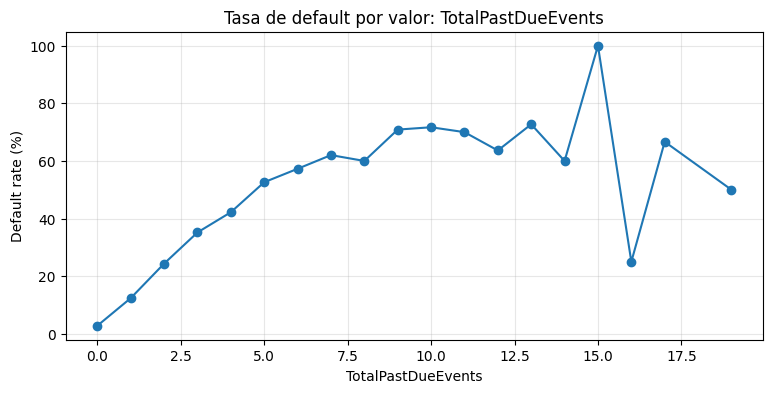

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 2.0]",19213,0.0950,0.0000,2.0000,9.5040
1,"(2.0, 2.333]",2722,0.0602,2.0714,2.3333,6.0250
2,"(2.333, 3.0]",17648,0.0600,2.3571,3.0000,6.0007
3,"(3.0, 3.333]",2405,0.0590,3.1000,3.3333,5.9044
4,"(3.333, 4.0]",16356,0.0560,3.3750,4.0000,5.6004
5,"(4.0, 4.5]",4879,0.0531,4.1429,4.5000,5.3085
6,"(4.5, 5.5]",12131,0.0636,4.6000,5.5000,6.3556
7,"(5.5, 6.5]",8624,0.0602,5.6000,6.5000,6.0181
8,"(6.5, 9.0]",12571,0.0649,6.5714,9.0000,6.4911
9,"(9.0, 56.0]",8120,0.0669,9.3333,56.0000,6.6872


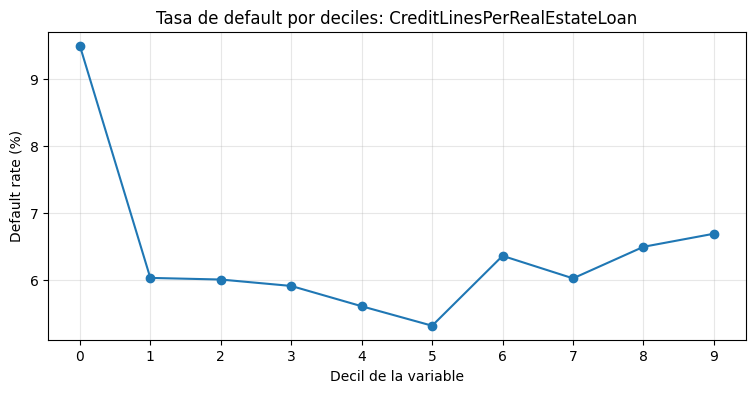

In [30]:
# ¿Cómo aumenta la tasa de default cuando aumenta cada variable?
# Para variables continuas utilizamos deciles.
# Para variables discretas (conteos, binarias, etc.) agrupamos por su valor.

def default_rate_by_bins(
    df: pd.DataFrame,
    feature: str,
    target: str = TARGET,
    q: int = 10,
    max_unique_discrete: int = 20,
) -> tuple[pd.DataFrame, str]:
    """
    Calcula la tasa de default según una variable.

    - Variables continuas  -> agrupación por cuantiles (qcut).
    - Variables discretas  -> agrupación por valor.
    """

    temp = df[[feature, target]].copy()

    # Número de valores distintos
    n_unique = temp[feature].nunique(dropna=True)

    # ------------------------------------------------------------------
    # Variable discreta
    # ------------------------------------------------------------------
    if n_unique <= max_unique_discrete:

        result = (
            temp
            .groupby(feature, observed=True)
            .agg(
                n=(target, "size"),
                default_rate=(target, "mean"),
            )
            .reset_index()
            .rename(columns={feature: "bin"})
        )

        result["feature_min"] = result["bin"]
        result["feature_max"] = result["bin"]

        grouping_type = "discrete"

    # ------------------------------------------------------------------
    # Variable continua
    # ------------------------------------------------------------------
    else:

        temp["bin"] = pd.qcut(
            temp[feature],
            q=q,
            duplicates="drop",
        )

        result = (
            temp
            .groupby("bin", observed=True)
            .agg(
                n=(target, "size"),
                default_rate=(target, "mean"),
                feature_min=(feature, "min"),
                feature_max=(feature, "max"),
            )
            .reset_index()
        )

        grouping_type = "continuous"

    result["default_rate_pct"] = 100 * result["default_rate"]

    return result, grouping_type


# ================================================================
# Visualización
# ================================================================

for feature in FINAL_FEATURES:

    dr, grouping_type = default_rate_by_bins(train_fe, feature)

    display(dr)

    plt.figure(figsize=(9, 4))

    if grouping_type == "continuous":

        plt.plot(
            range(len(dr)),
            dr["default_rate_pct"],
            marker="o",
        )

        plt.xticks(range(len(dr)))
        plt.xlabel("Decil de la variable")
        plt.title(f"Tasa de default por deciles: {feature}")

    else:

        plt.plot(
            dr["bin"],
            dr["default_rate_pct"],
            marker="o",
        )

        plt.xlabel(feature)
        plt.title(f"Tasa de default por valor: {feature}")

    plt.ylabel("Default rate (%)")
    plt.grid(alpha=0.3)

    plt.show()

En general, se observa una relación clara entre los distintos grupos de cada variable y la tasa de *default*. 
A medida que se avanza entre los deciles (o entre las categorías en el caso de variables discretas), 
la probabilidad de impago varía de forma consistente, lo que indica que las variables contienen información
relevante para discriminar entre clientes de mayor y menor riesgo y, por tanto,
resultan adecuadas para el desarrollo de modelos predictivos.


## 10. Correlaciones

Calculamos dos tipos:

- **Pearson**: relación lineal.
- **Spearman**: relación monótona, más robusta ante outliers y no linealidades.

También miramos la correlación absoluta con el target. Esto no decide por sí solo qué variables usar, pero ayuda a entender qué variables están más relacionadas con el evento de mora.

In [31]:
feature_cols_for_corr = [c for c in train_fe.columns if c != TARGET]

corr_pearson = train_fe[[TARGET] + feature_cols_for_corr].corr(method="pearson")
corr_spearman = train_fe[[TARGET] + feature_cols_for_corr].corr(method="spearman")

target_corr = pd.DataFrame({
    "feature": feature_cols_for_corr,
    "pearson_with_target": corr_pearson.loc[feature_cols_for_corr, TARGET].values,
    "spearman_with_target": corr_spearman.loc[feature_cols_for_corr, TARGET].values,
})

target_corr["abs_pearson"] = target_corr["pearson_with_target"].abs()
target_corr["abs_spearman"] = target_corr["spearman_with_target"].abs()

target_corr.sort_values("abs_spearman", ascending=False).head(20)

,feature,pearson_with_target,spearman_with_target,abs_pearson,abs_spearman
6,NumberOfTimes90DaysLate,0.3151,0.3359,0.3151,0.3359
24,TotalPastDueEvents_log1p,0.3873,0.3355,0.3873,0.3355
14,TotalPastDueEvents,0.3913,0.3355,0.3913,0.3355
16,Has90DaysLate,0.3332,0.3332,0.3332,0.3332
15,HasAnyPastDue,0.3102,0.3102,0.3102,0.3102
8,NumberOfTime60-89DaysPastDueNotWorse,0.2708,0.2702,0.2708,0.2702
2,NumberOfTime30-59DaysPastDueNotWorse,0.2695,0.2470,0.2695,0.2470
19,RevolvingUtilizationOfUnsecuredLines_log1p,0.1859,0.2403,0.1859,0.2403
0,RevolvingUtilizationOfUnsecuredLines,-0.0004,0.2403,0.0004,0.2403
1,age,-0.1165,-0.1181,0.1165,0.1181


<Figure size 1400x1400 with 0 Axes>

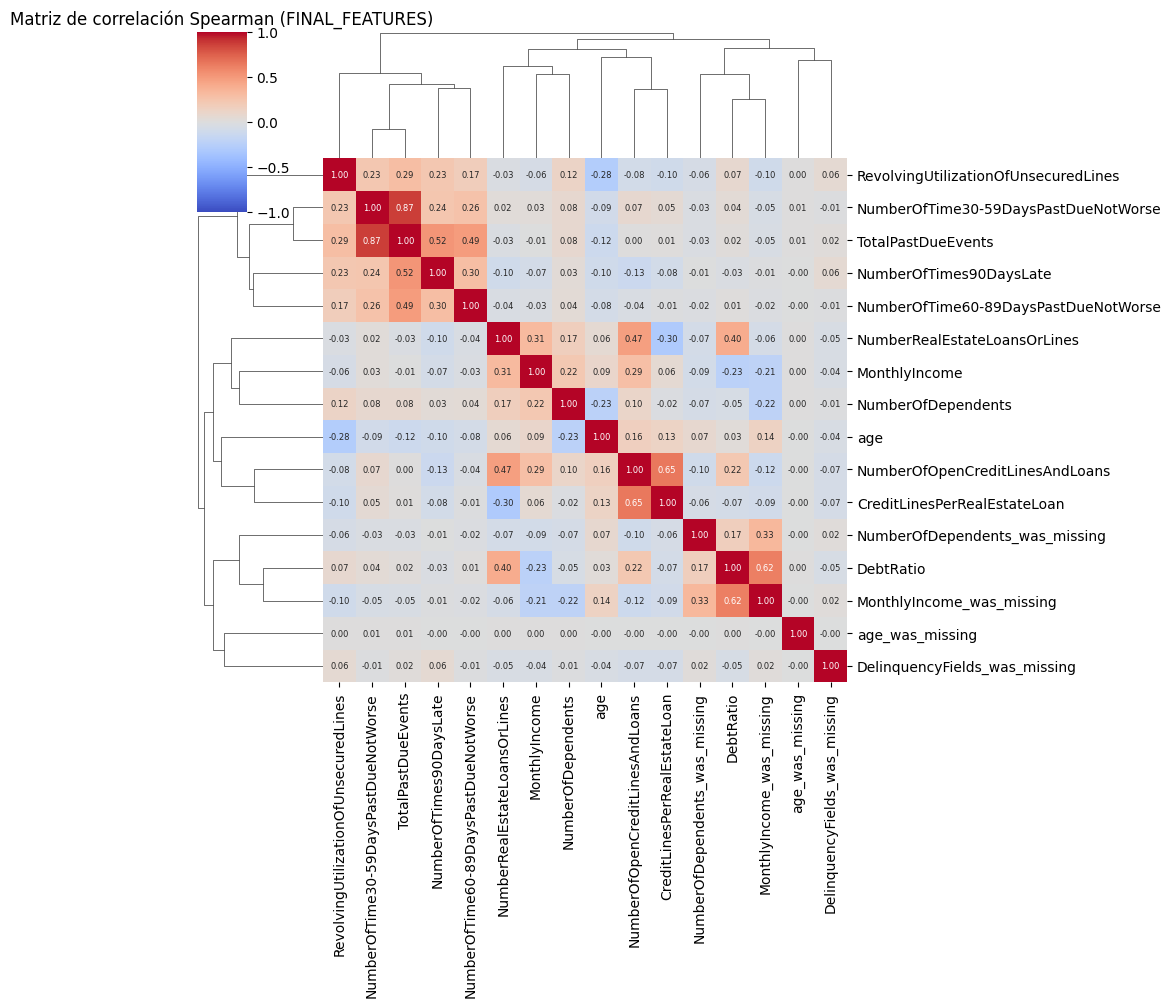

In [32]:
# Heatmap de correlación Spearman
# IMPORTANTE: usamos FINAL_FEATURES (las 16 variables que realmente entran
# al modelo), NO todas las columnas de train_fe. Así el mapa que veis aquí
# es coherente con lo que se usará en la Práctica 2: ya no aparecerán los
# pares _log1p ni los indicadores binarios que decidimos descartar arriba.
plot_cols = FINAL_FEATURES

corr = train_fe[plot_cols].corr(method="spearman")

plt.figure(figsize=(14, 14))

sns.clustermap(
    corr,
    annot=True,      # Escribe el número
    fmt=".2f",       # Dos decimales
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 6}
)

plt.title("Matriz de correlación Spearman (FINAL_FEATURES)")
plt.show()


### 10.1 (Opcional) Heatmap con todas las columnas, incluidas las descartadas

Este segundo mapa incluye también las versiones `_log1p` y los indicadores binarios derivados que excluimos de `FINAL_FEATURES`. Solo sirve para visualizar de un vistazo por qué se descartaron (deberíais ver bloques rojo intenso, correlación ≈ 1, entre cada variable y su versión derivada). No es necesario para el modelado, es puramente ilustrativo para la memoria.

<Figure size 2000x2000 with 0 Axes>

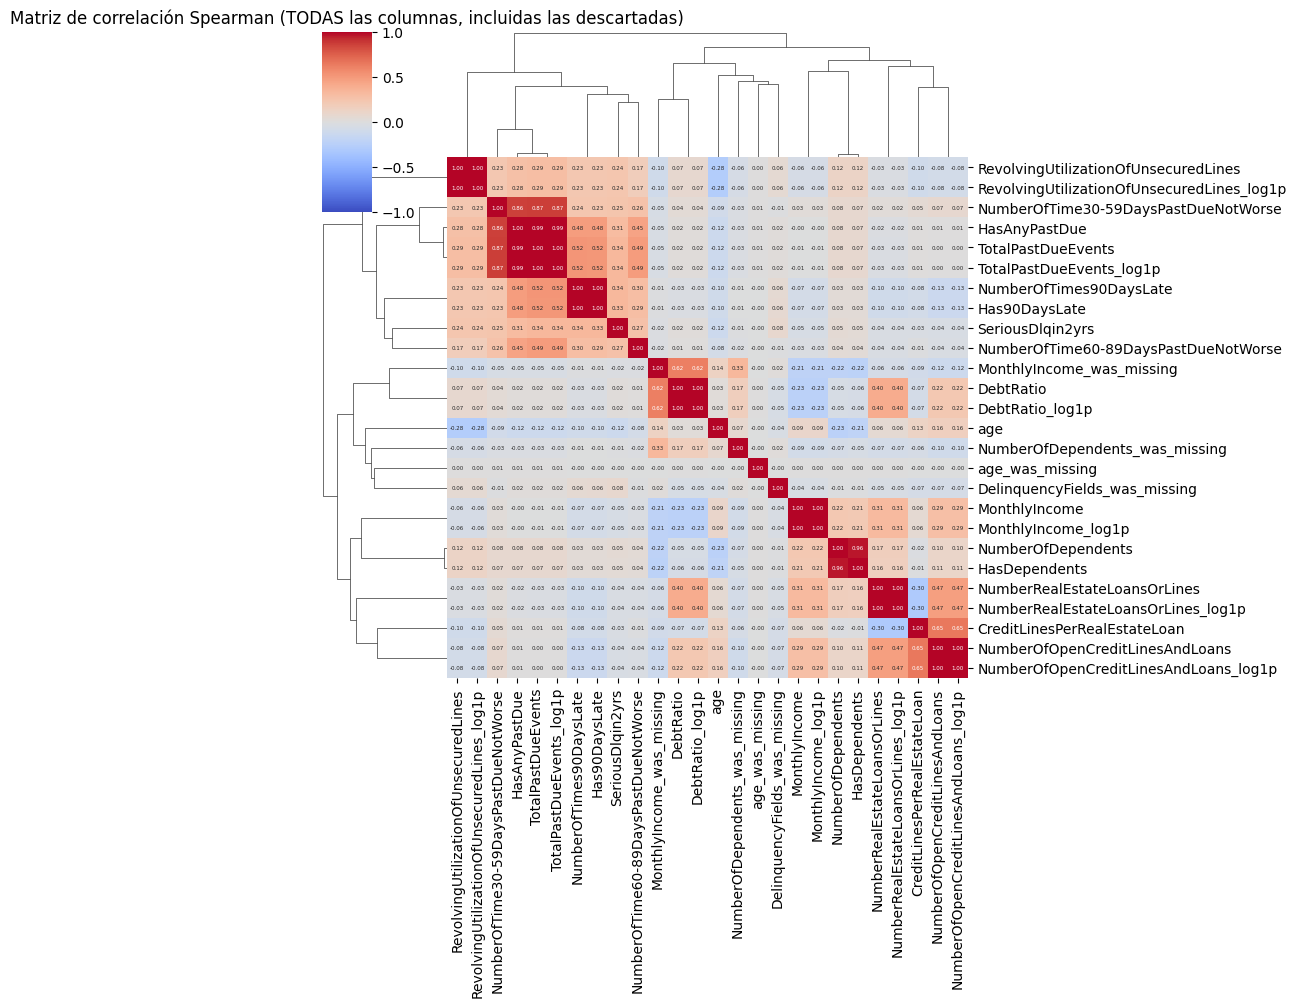

In [33]:
plot_cols_all = train_fe.columns

corr_all = train_fe[plot_cols_all].corr(method="spearman")

plt.figure(figsize=(20, 20))

sns.clustermap(
    corr_all,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 4}
)

plt.title("Matriz de correlación Spearman (TODAS las columnas, incluidas las descartadas)")
plt.show()


In [34]:
def high_correlation_pairs(corr_matrix: pd.DataFrame, threshold: float = 0.90) -> pd.DataFrame:
    """Devuelve pares de variables con correlación absoluta superior al umbral."""
    pairs = []
    cols = corr_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            value = corr_matrix.iloc[i, j]
            if abs(value) >= threshold:
                pairs.append({
                    "feature_1": cols[i],
                    "feature_2": cols[j],
                    "correlation": value,
                    "abs_correlation": abs(value),
                })

    columns = ["feature_1", "feature_2", "correlation", "abs_correlation"]
    if not pairs:
        return pd.DataFrame(columns=columns)

    return pd.DataFrame(pairs).sort_values("abs_correlation", ascending=False)


# 1) Sobre TODAS las columnas (incluye las versiones log1p y los indicadores
#    binarios que calculamos pero no usamos en el modelo). Esperamos ver aquí
#    los pares redundantes: es la confirmación de por qué los hemos excluido
#    de FINAL_FEATURES.
high_corr_all = high_correlation_pairs(train_fe[feature_cols_for_corr].corr(method="spearman"), threshold=0.90)
print(f"Pares con |correlación Spearman| >= 0.90 entre TODAS las columnas: {len(high_corr_all)}")
display(high_corr_all)

# 2) Sobre las features que realmente entran al modelo (FINAL_FEATURES).
#    Si esta tabla sale vacía, confirma que ya no hay redundancias fuertes
#    en el conjunto final de variables.
high_corr = high_correlation_pairs(train_fe[FINAL_FEATURES].corr(method="spearman"), threshold=0.90)
print(f"\nPares con |correlación Spearman| >= 0.90 dentro de FINAL_FEATURES: {len(high_corr)}")
display(high_corr)


Pares con |correlación Spearman| >= 0.90 entre TODAS las columnas: 10


,feature_1,feature_2,correlation,abs_correlation
5,NumberRealEstateLoansOrLines,NumberRealEstateLoansOrLines_log1p,1.0000,1.0000
3,NumberOfOpenCreditLinesAndLoans,NumberOfOpenCreditLinesAndLoans_log1p,1.0000,1.0000
8,TotalPastDueEvents,TotalPastDueEvents_log1p,1.0000,1.0000
0,RevolvingUtilizationOfUnsecuredLines,RevolvingUtilizationOfUnsecuredLines_log1p,1.0000,1.0000
1,DebtRatio,DebtRatio_log1p,1.0000,1.0000
2,MonthlyIncome,MonthlyIncome_log1p,1.0000,1.0000
4,NumberOfTimes90DaysLate,Has90DaysLate,0.9996,0.9996
7,TotalPastDueEvents,HasAnyPastDue,0.9933,0.9933
9,HasAnyPastDue,TotalPastDueEvents_log1p,0.9933,0.9933
6,NumberOfDependents,HasDependents,0.9632,0.9632



Pares con |correlación Spearman| >= 0.90 dentro de FINAL_FEATURES: 0


,feature_1,feature_2,correlation,abs_correlation


**Cómo leer esta celda:** la primera tabla (todas las columnas) debería mostrar los pares `variable` / `variable_log1p` con correlación muy alta -esperado, es la razón por la que los excluimos-. La segunda tabla (`FINAL_FEATURES`) es la que de verdad importa: si sale vacía, confirma que el conjunto de variables que entra al modelo no tiene redundancias fuertes. Si aparece algún par ahí, hay que decidir explícitamente cuál de las dos variables se descarta antes de seguir a la Práctica 2.

## 11. Mutual Information

La correlación mide relaciones lineales o monótonas. `Mutual Information` puede detectar relaciones más generales entre una variable y el target. No presupone linealidad.

In [35]:
# Mutual information requiere que no haya NaN. Ya imputamos previamente.
X_mi = train_fe[FINAL_FEATURES].astype(float)
y_mi = train_fe[TARGET].astype(int)

mi_values = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_table = pd.DataFrame({"feature": FINAL_FEATURES, "mutual_information": mi_values})
mi_table = mi_table.sort_values("mutual_information", ascending=False)
mi_table.head(20)

,feature,mutual_information
14,TotalPastDueEvents,0.0477
0,RevolvingUtilizationOfUnsecuredLines,0.0372
6,NumberOfTimes90DaysLate,0.0302
2,NumberOfTime30-59DaysPastDueNotWorse,0.0257
8,NumberOfTime60-89DaysPastDueNotWorse,0.0203
1,age,0.0085
15,CreditLinesPerRealEstateLoan,0.0059
5,NumberOfOpenCreditLinesAndLoans,0.0053
7,NumberRealEstateLoansOrLines,0.0045
3,DebtRatio,0.0044


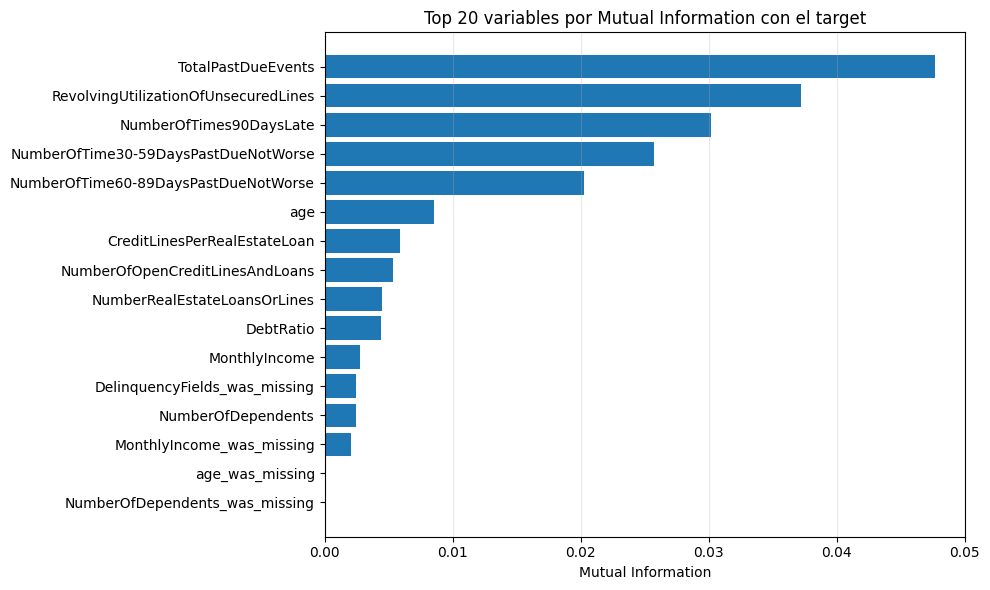

In [36]:
plt.figure(figsize=(10, 6))
top_mi = mi_table.head(20).iloc[::-1]
plt.barh(top_mi["feature"], top_mi["mutual_information"])
plt.title("Top 20 variables por Mutual Information con el target")
plt.xlabel("Mutual Information")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 12. PCA

PCA no se usará necesariamente en el modelo final, porque reduce interpretabilidad. Sin embargo, es útil para:

- detectar redundancia entre variables;
- visualizar si hay separación natural entre clases;
- entender cuánta varianza se concentra en pocos componentes.

Como PCA es sensible a escala, usamos `StandardScaler`.

In [37]:
# Escalado de features para PCA.
pca_scaler = StandardScaler()
X_scaled = pca_scaler.fit_transform(train_fe[FINAL_FEATURES].astype(float))

pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
})
explained["cumulative_explained_variance"] = explained["explained_variance_ratio"].cumsum()

explained.head(15)

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.1600,0.1600
1,2,0.1252,0.2852
2,3,0.1085,0.3937
3,4,0.0925,0.4862
4,5,0.0657,0.5519
5,6,0.0625,0.6144
6,7,0.0625,0.6769
7,8,0.0618,0.7387
8,9,0.0595,0.7981
9,10,0.0481,0.8462


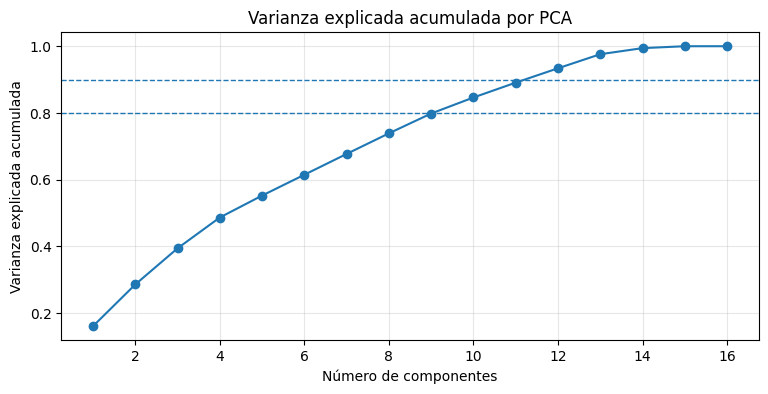

In [38]:
plt.figure(figsize=(9, 4))
plt.plot(explained["component"], explained["cumulative_explained_variance"], marker="o")
plt.axhline(0.80, linestyle="--", linewidth=1)
plt.axhline(0.90, linestyle="--", linewidth=1)
plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(alpha=0.3)
plt.show()

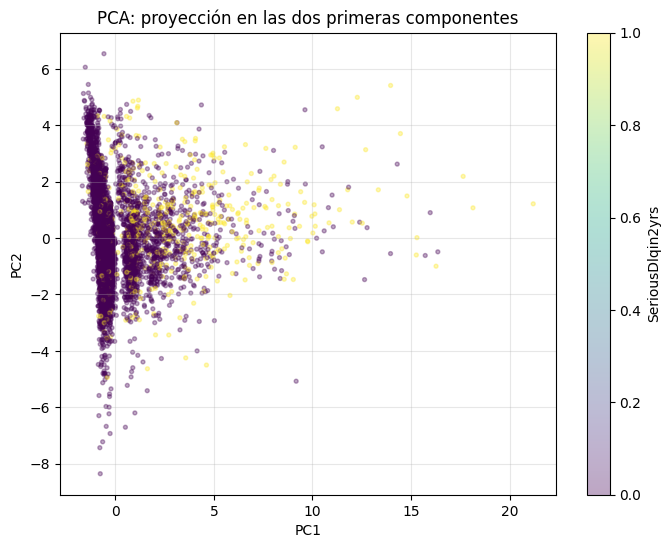

In [39]:
# Visualización 2D de los dos primeros componentes.
# Muestreamos para que el gráfico sea legible y rápido.
plot_sample = train_fe.sample(n=min(10000, len(train_fe)), random_state=RANDOM_STATE).index

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[plot_sample, 0],
    X_pca[plot_sample, 1],
    c=train_fe.loc[plot_sample, TARGET],
    alpha=0.35,
    s=8,
)
plt.title("PCA: proyección en las dos primeras componentes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="SeriousDlqin2yrs")
plt.grid(alpha=0.3)
plt.show()

In [40]:
# Loadings: peso de cada variable en cada componente.
loadings = pd.DataFrame(
    pca.components_.T,
    index=FINAL_FEATURES,
    columns=[f"PC{i}" for i in range(1, len(FINAL_FEATURES) + 1)]
)

# Variables con más peso absoluto en las primeras componentes.
for pc in ["PC1", "PC2", "PC3"]:
    print("\n", pc)
    display(loadings[pc].abs().sort_values(ascending=False).head(10).to_frame("abs_loading"))


 PC1


,abs_loading
TotalPastDueEvents,0.6135
NumberOfTime30-59DaysPastDueNotWorse,0.4748
NumberOfTime60-89DaysPastDueNotWorse,0.4249
NumberOfTimes90DaysLate,0.4190
age,0.1320
NumberOfDependents,0.0977
MonthlyIncome_was_missing,0.0897
DebtRatio,0.0594
NumberOfDependents_was_missing,0.0544
NumberRealEstateLoansOrLines,0.0169



 PC2


,abs_loading
MonthlyIncome_was_missing,0.5020
NumberOfOpenCreditLinesAndLoans,0.4308
MonthlyIncome,0.3634
DebtRatio,0.3514
NumberOfDependents_was_missing,0.3056
CreditLinesPerRealEstateLoan,0.2792
NumberOfDependents,0.2447
NumberRealEstateLoansOrLines,0.2193
NumberOfTimes90DaysLate,0.1178
DelinquencyFields_was_missing,0.0784



 PC3


,abs_loading
NumberOfOpenCreditLinesAndLoans,0.5305
DebtRatio,0.4577
MonthlyIncome_was_missing,0.3637
CreditLinesPerRealEstateLoan,0.3203
NumberRealEstateLoansOrLines,0.3054
age,0.3052
NumberOfTime30-59DaysPastDueNotWorse,0.1502
NumberOfDependents_was_missing,0.1465
NumberOfDependents,0.1198
DelinquencyFields_was_missing,0.1059


## 13. Guardado de datasets y objetos

Guardamos:

- `preprocessed_train.csv`
- `preprocessed_prod.csv`
- lista de features finales
- imputador KNN
- límites de clipping
- resúmenes EDA

Los notebooks siguientes parten de estos ficheros para asegurar reproducibilidad.

In [41]:
# Validaciones finales antes de guardar.
assert train_fe[TARGET].isna().sum() == 0, "El target de construcción no debe tener NaN."
assert prod_fe[TARGET].isna().sum() == len(prod_fe), "El target de producción debe permanecer vacío antes de predecir."
assert train_fe[FINAL_FEATURES].isna().sum().sum() == 0, "Quedan NaN en features de construcción."
assert prod_fe[FINAL_FEATURES].isna().sum().sum() == 0, "Quedan NaN en features de producción."

train_fe.to_csv(OUTPUT_DIR / "preprocessed_train.csv", index=False)
prod_fe.to_csv(OUTPUT_DIR / "preprocessed_prod.csv", index=False)

joblib.dump({
    "target": TARGET,
    "original_features": FEATURES,
    "final_features": FINAL_FEATURES,
    "missing_flag_cols": missing_flag_cols,
    "imputer": knn_imputer,
    "clipping_limits": clipping_limits,
    "pca_scaler": pca_scaler,
    "pca": pca,
}, OBJECTS_DIR / "preprocessing_objects.joblib")

mi_table.to_csv(OUTPUT_DIR / "mutual_information.csv", index=False)
target_corr.to_csv(OUTPUT_DIR / "target_correlations.csv", index=False)
high_corr.to_csv(OUTPUT_DIR / "high_correlations.csv", index=False)
explained.to_csv(OUTPUT_DIR / "pca_explained_variance.csv", index=False)

print("Ficheros guardados en:", OUTPUT_DIR.resolve())
print("Objetos guardados en:", OBJECTS_DIR.resolve())

Ficheros guardados en: /home/claude/work/outputs
Objetos guardados en: /home/claude/work/outputs/objects


## 14. Conclusiones del EDA y preprocesado

Puntos que deberías comentar en la memoria o presentación:

1. El problema está desbalanceado: hay muchos más clientes sin morosidad grave que con morosidad grave.
2. Las variables de retrasos pasados son candidatas muy fuertes para predecir el riesgo futuro.
3. Hay variables con colas extremadamente largas, especialmente ratios financieros. Por eso se ha aplicado clipping conservador.
4. Los valores perdidos se han tratado con KNN, pero conservando flags de ausencia para no perder información potencialmente relevante.
5. PCA se usa como análisis, no como transformación principal, porque el objetivo de la práctica incluye XAI y conviene conservar variables interpretables.
6. El dataset preprocesado queda listo para entrenar modelos de caja negra: red neuronal y aprendizaje por refuerzo contextual.